## Sales & Profitability Analysis — **Yandex Market**

#### Project objective

The objective of this project is to analyze sales and profitability of an online store Yandex Market and to identify practical opportunities to improve profit.

The analysis focuses not only on sales and revenue, but primarily on product profitability, pricing, assortment, marketplace costs, promotions and inventory management.

**Key business questions**

#### The analysis aims to answer the following questions:

* Which SKUs and product groups are the main profit drivers?
* Which products generate high revenue but have low or negative profitability?
* Where are there opportunities to increase profit within the existing assortment?
* Which products may have pricing opportunities?
* How did changes in price and discounts relate to sales volume and profit?
* Where is profit potentially lost because of marketplace costs, out-of-stock situations, excessive inventory or returns?
* Which actions should be prioritized over the next 90 days?

**Table of Contents**:

1. Data Loading and Preprocessing
2. Data Mart: Sales by SKU and Month
3. Unit Economics Calculation
4. Unit Economics at Different Levels: SKU, Category, Month and Cluster
5. SKU Segmentation: Sales vs. Profit Margin
6. Price and Discount Analysis
7. Sales Funnel Analysis: Organic Sales without Advertising
8. Profit Loss Analysis: Stockouts, Excess Inventory, Returns and Unpurchased Orders
9. Conclusions and Recommendations

**Data and methodology**

The analysis is based on monthly marketplace reports from Yandex Market. The sales data was combined into analytical datasets at SKU-month level.

A separate COGS dataset was joined by SKU to calculate total product cost and final profit.

The analysis includes monthly and SKU-level profitability, profit margin, sales volume, product segmentation, sales variability, pricing analysis and inventory analysis.

For inventory analysis, the available stock reports were used. 

**Tools**
Python, Pandas, Matplotlib,Jupyter Notebook, NumPy

In [1]:
import pandas as pd
import glob
import argparse
import sys
import os
import openpyxl
import re
import numpy as np
import matplotlib.pyplot as plt




# We use 30 days to estimate future losses.
# This is a business assumption.
LOSS_PROJECTION_DAYS = 30


# Inventory turnover limit (in days) above which stock is considered excessive.
# IMPORTANT: The "Turnover" field in the source file is measured in DAYS.
# It shows approximately how many days a product stays in stock.
# Therefore, we use 182 days as the limit for six months.
EXCESS_TURNOVER_DAYS = 182

## 1. Data Loading and Preprocessing


#### 1.1 Remains: clusters, warehouses, categories
###### File `fulfillment_offer_analytics...`

In [126]:
stock_files = glob.glob(
    os.path.expanduser("~/Desktop/reports/yandex/fulfillment_offer_analytics*.xlsx")
)

print(f"Files found: {len(stock_files)}")

for file in stock_files:
    print(file)

Files found: 1
/Users/sweetyolo/Desktop/reports/yandex/fulfillment_offer_analytics_123729110_08-07-2026 (3).xlsx


In [3]:
## Load current stock snapshot
# The Excel file contains several sheets with different stock views

stock_file = stock_files[0] 

# Sheet "Stock by cities"(Остатки по кластерам) - headers are located in the 7th row (header=6 because pandas uses zero-based indexing)
stock_cluster = pd.read_excel(stock_file, sheet_name="Остатки по кластерам", header=6)
stock_cluster = stock_cluster.rename(columns={"Ваш SSKU": "sku"})

# Sheet "Stock by warehouses"(Остатки по складам) - headers are located in the 6th row
stock_warehouse = pd.read_excel(stock_file, sheet_name="Остатки по складам", header=5)
stock_warehouse = stock_warehouse.rename(columns={"Ваш SSKU": "sku"})

# Sheet "Categories"(Категории) - headers are located in the 5th row
# This sheet does not contain SKU information, only the mapping between Cluster and Category
categories_cluster = pd.read_excel(stock_file, sheet_name="Категории", header=4)

print("stock by city:", stock_cluster.shape)
print("warehouse stock:", stock_warehouse.shape)
print("Category (city x category):", categories_cluster.shape)


stock by city: (423, 22)
warehouse stock: (409, 10)
Category (city x category): (12, 6)


In [4]:
display(stock_cluster.head())


,SSKU,sku,Название товара,Кластер,Годный,Резерв,Ожидается,Карантин,Брак,Просрочен,...,"Среднесуточный объём проданных товаров, л","Среднесуточный объём товаров на складе, л",Оборачиваемость,Прогноз хранения,Доля локальных продаж,Расходы на среднюю милю,15-06 - 21-06,22-06 - 28-06,29-06 - 05-07,06-07 - 08-07
0,стикерпак_3D,стикерпак_3D,Стикерпак 3D наклейки для доноров крови от Don...,Самара,7,0,0.0,0,0,0,...,0.004,0.961,218.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0
1,стикерпак_3D,стикерпак_3D,Стикерпак 3D наклейки для доноров крови от Don...,Москва,0,0,0.0,0,0,0,...,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,1.0,0.0
2,стикерпак_3D,стикерпак_3D,Стикерпак 3D наклейки для доноров крови от Don...,Ростов,4,0,0.0,0,0,0,...,0.013,0.666,50.3,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,стикерпак_3D,стикерпак_3D,Стикерпак 3D наклейки для доноров крови от Don...,Екатеринбург,8,0,0.0,0,0,0,...,0.000,1.093,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,майка_S,майка_S,"Майка спортивная беговая, Размер S, красная, п...",Москва,2,0,0.0,0,0,0,...,0.036,2.304,64.0,NaN,0.0,0.0,0.0,0.0,1.0,0.0


In [5]:
## Calculate inventory and inventory turnover metrics at the SKU level
# Aggregate stock values across clusters (sum/average, depending on the metric)
stock_sku = stock_cluster.groupby("sku").agg(
    stock_available=("Годный", "sum"),               # Available stock (sellable units)
    sales_30d=("Продажи 30 дн", "sum"),                 # Sales over the last 30 days (units)
    avg_daily_sales_l=("Среднесуточный объём проданных товаров, л", "sum"),
    avg_daily_stock_l=("Среднесуточный объём товаров на складе, л", "sum"),
    turnover_days=("Оборачиваемость", "mean"),          # Average days in stock (averaged across clusters)
    restock_recommended=("Рекомендуем поставить", "sum"),  # Marketplace forecast - stock shortage indicator
).reset_index()

# Missing values most likely indicate that there were no sales or no stock
# in a particular cluster, so replace them with 0 
stock_sku = stock_sku.fillna(0)

print("SKU-level inventory:", stock_sku.shape)
stock_sku.head()

SKU-level inventory: (123, 7)


,sku,stock_available,sales_30d,avg_daily_sales_l,avg_daily_stock_l,turnover_days,restock_recommended
0,heart_black_lxl,0,1490.0,0.054,0.000,0.0,0.0
1,heart_black_sm,3,0.0,0.000,5.022,0.0,0.0
2,heart_red_lxl,0,0.0,0.000,0.000,0.0,0.0
3,heart_red_sm,0,0.0,0.000,0.000,0.0,0.0
4,smile_black_lxl,0,0.0,0.000,0.918,0.0,0.0


#### 1.2  Sales Funnel Analysis (Impressions → Add to Cart → Orders → Deliveries)

There are multiple `sales_funnel_report...` files, each containing a different data slice. However, the reporting period is not stored inside the files, as the marketplace does not export this information.

Therefore, all files are combined into a single dataset, and each record is labeled with the source file name (`source_file`). Sales funnel metrics are then calculated using the aggregated data from all files.

**Limitation:** Since the reporting period is unavailable for each file, it is not possible to build a monthly sales funnel trend. The analysis provides only an overall view across all available reports.

In [6]:
funnel_files = glob.glob(
    os.path.expanduser("~/Desktop/reports/yandex/sales_funnel_report*.xlsx")
)

print(f"Files found: {len(funnel_files)}")

for file in funnel_files:
    print(file)

Files found: 13
/Users/sweetyolo/Desktop/reports/yandex/sales_funnel_report - October 2025.xlsx
/Users/sweetyolo/Desktop/reports/yandex/sales_funnel_report - July 2025.xlsx
/Users/sweetyolo/Desktop/reports/yandex/sales_funnel_report - June 2026.xlsx
/Users/sweetyolo/Desktop/reports/yandex/sales_funnel_report- May 2026.xlsx
/Users/sweetyolo/Desktop/reports/yandex/sales_funnel_report - February 2026.xlsx
/Users/sweetyolo/Desktop/reports/yandex/sales_funnel_report - July 2026.xlsx
/Users/sweetyolo/Desktop/reports/yandex/sales_funnel_report - January 2026.xlsx
/Users/sweetyolo/Desktop/reports/yandex/sales_funnel_report - March 2026.xlsx
/Users/sweetyolo/Desktop/reports/yandex/sales_funnel_report - November 2025.xlsx
/Users/sweetyolo/Desktop/reports/yandex/sales_funnel_report- April 2026.xlsx
/Users/sweetyolo/Desktop/reports/yandex/sales_funnel_report - August 2025.xlsx
/Users/sweetyolo/Desktop/reports/yandex/sales_funnel_report - September 2025.xlsx
/Users/sweetyolo/Desktop/reports/yandex/

In [7]:
funnel_frames = []
for f in funnel_files:
    df = pd.read_excel(f, sheet_name="Аналитика продаж", header=0)
    df["source_file"] = f.split("/")[-1] # is created new column 
    funnel_frames.append(df)

funnel = pd.concat(funnel_frames, ignore_index=True)

funnel = funnel.rename(columns={
    "Ваш SKU": "sku",
    "Категория": "category",
    "Показы моих товаров, шт.": "impressions",
    "Добавления в корзину, шт.": "cart_adds",
    "Заказанные товары, шт.": "ordered_qty",
    "Заказано товаров на сумму, ₽": "ordered_amount",
    "Доставлено за период, шт.": "delivered_qty",
    "Доставлено за период на сумму, ₽": "delivered_amount",
})

funnel_numeric_cols = ["impressions", "cart_adds", "ordered_qty", "ordered_amount",
                        "delivered_qty", "delivered_amount"]
funnel[funnel_numeric_cols] = funnel[funnel_numeric_cols].fillna(0)

print("Total number of rows in the combined sales funnel dataset::", funnel.shape[0])
funnel.head()


Total number of rows in the combined sales funnel dataset:: 1002


/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/

,category,Бренд,sku,Название товара,"Индекс видимости, %",impressions,cart_adds,ordered_qty,ordered_amount,"Конверсия из корзины в заказ, %","Доля заказанных товаров с бустом, %",delivered_qty,delivered_amount,source_file
0,"Одежда, обувь и аксессуары · Одежда для взросл...",DonorSearch,ф_бег_S,"Футболка спортивная беговая, Размер S , красна...",30,998.0,4.0,0.0,0.0,NaN,NaN,1.0,1719.0,sales_funnel_report - October 2025.xlsx
1,"Одежда, обувь и аксессуары · Одежда для взросл...",DonorSearch,ф_донор_L,"Футболка ""Донор крови, донор жизни!"", Размер L...",20,232.0,2.0,0.0,0.0,NaN,NaN,0.0,0.0,sales_funnel_report - October 2025.xlsx
2,"Одежда, обувь и аксессуары · Сумки и аксессуар...",DonorSearch,шоппер_красный,Сумка шоппер от Сообщества доноров DonorSearch...,50,3626.0,13.0,0.0,0.0,NaN,NaN,0.0,0.0,sales_funnel_report - October 2025.xlsx
3,Товары для дома · Товары для праздников · Дипл...,DonorSearch,значок_друзья,Металлический значок DonorSearch для друзей со...,38,2002.0,6.0,1.0,996.0,16.67,100.0,1.0,996.0,sales_funnel_report - October 2025.xlsx
4,"Одежда, обувь и аксессуары · Одежда для взросл...",DonorSearch,ф_бег_XL,"Футболка спортивная беговая, Размер XL, красна...",43,1835.0,4.0,0.0,0.0,NaN,NaN,1.0,1736.0,sales_funnel_report - October 2025.xlsx


In [8]:
# Product category is taken from this dataset because
# the inventory report does not provide category information at the SKU level.
sku_category = (
    funnel.groupby("sku")["category"]
    .agg(lambda x: x.mode().iloc[0])  # Assign the most frequently occurring category to each SKU.
    .reset_index()
)

# Aggregate sales funnel metrics by SKU across all source files.
funnel_sku = funnel.groupby("sku")[funnel_numeric_cols].sum().reset_index()
funnel_sku["cart_conversion_pct"] = np.where(
    funnel_sku["cart_adds"] > 0,
    funnel_sku["ordered_qty"] / funnel_sku["cart_adds"] * 100,
    0,
)

print("SKU-to-category mapping:", sku_category.shape[0])
print("SKU-level sales funnel summary:", funnel_sku.shape[0])
funnel_sku.head()


SKU-to-category mapping: 130
SKU-level sales funnel summary: 130


,sku,impressions,cart_adds,ordered_qty,ordered_amount,delivered_qty,delivered_amount,cart_conversion_pct
0,103517112704,17.0,0.0,0.0,0.0,0.0,0.0,0.0
1,103690438084,8.0,0.0,0.0,0.0,0.0,0.0,0.0
2,103792271589,15.0,0.0,0.0,0.0,0.0,0.0,0.0
3,103792321855,12.0,0.0,0.0,0.0,0.0,0.0,0.0
4,103792405815,2.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
sku_category.head(20)

,sku,category
0,103517112704,"Одежда, обувь и аксессуары · Сумки и аксессуар..."
1,103690438084,Товары для дома · Товары для праздников · Дипл...
2,103792271589,"Одежда, обувь и аксессуары · Сумки и аксессуар..."
3,103792321855,Авто · Аксессуары и оборудование · Защита и вн...
4,103792405815,Спорт и отдых · Тренажеры и фитнес · Фитнес · ...
5,103831932631,"Одежда, обувь и аксессуары · Сумки и аксессуар..."
6,37231951.DON77776673,"Одежда, обувь и аксессуары · Сумки и аксессуар..."
7,37231951.heart_red_lxl,"Одежда, обувь и аксессуары · Одежда для взросл..."
8,37231952.DON77776666,"Одежда, обувь и аксессуары · Сумки и аксессуар..."
9,4690339618,"Одежда, обувь и аксессуары · Сумки и аксессуар..."


#### 1.3  Uploading all excel files "united_orders"

In [10]:
orders_files = glob.glob(
    os.path.expanduser("~/Desktop/reports/yandex/united_orders/*.xlsx")
)

print(f"Files found: {len(orders_files)}")

for file in orders_files:
    print(file)

Files found: 24
/Users/sweetyolo/Desktop/reports/yandex/united_orders/united_orders_93439471_01-10-2024_31-10-2024.xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_orders/united_orders_93439471_01-03-2026_31-03-2026.xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_orders/united_orders_93439471_01-02-2025_28-02-2025.xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_orders/united_orders_93439471_01-09-2025_30-09-2025.xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_orders/united_orders_93439471_01-01-2026_31-01-2026.xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_orders/united_orders_93439471_01-08-2025_31-08-2025.xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_orders/united_orders_93439471_01-12-2024_31-12-2024.xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_orders/united_orders_93439471_01-11-2024_30-11-2024.xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_orders/united_orders_93439471_01-09-2024_30-09-2024.xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_o

In [11]:
orders_sheet = "Услуги и маржа по заказам"

all_orders = []

for file_path in orders_files:

    xls = pd.ExcelFile(file_path)


    # read tables
    if orders_sheet in xls.sheet_names:

        df = pd.read_excel(
            xls,
            sheet_name=orders_sheet,
            header=6
        )



        all_orders.append(df)

united_orders = pd.concat(all_orders, ignore_index=True)

/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/

In [12]:
display(united_orders.info())
display(united_orders.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5458 entries, 0 to 5457
Data columns (total 35 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   ID бизнес-аккаунта                                              5458 non-null   int64  
 1   Модели работы                                                   5458 non-null   object 
 2   ID магазинов                                                    5458 non-null   int64  
 3   Названия магазинов                                              5458 non-null   object 
 4   ИНН                                                             5458 non-null   int64  
 5   Номера договоров на размещение                                  5458 non-null   object 
 6   Номера договоров на продвижение                                 5458 non-null   object 
 7   Номер заказа                                       

None

,ID бизнес-аккаунта,Модели работы,ID магазинов,Названия магазинов,ИНН,Номера договоров на размещение,Номера договоров на продвижение,Номер заказа,Ваш номер заказа,Статус заказа,...,"Экспресс-доставка покупателю, ₽","Доставка из-за рубежа, ₽","Приём платежа покупателя, ₽","Перевод платежа покупателя, ₽","Организация забора заказов, ₽","Обработка заказов в СЦ или ПВЗ, ₽","Хранение невыкупов и возвратов, ₽","Обработка заказов на складе, ₽","Вознаграждение за продажу товара, ₽","Вывоз со склада, СЦ, ПВЗ, ₽"
0,123729115,FBY,123729110,DonorSearch Shop - Магазин сообщества доноров,1686035415,12104779/24,ОФ-8637971,566020977,566020977.0,Доставлен,...,0,0,0.24,20.69,0,0,0,0,0,NaN
1,123729115,FBY,123729110,DonorSearch Shop - Магазин сообщества доноров,1686035415,12104779/24,ОФ-8637971,560570400,560570400.0,Доставлен,...,0,0,0.12,102.47,0,0,0,0,0,NaN
2,123729115,FBY,123729110,DonorSearch Shop - Магазин сообщества доноров,1686035415,12104779/24,ОФ-8637971,552240545,552240545.0,Невыкуп принят на складе,...,0,0,0.00,0.00,0,0,0,0,0,NaN
3,123729115,FBY,123729110,DonorSearch Shop - Магазин сообщества доноров,1686035415,12104779/24,ОФ-8637971,570748855,570748855.0,Доставлен,...,0,0,0.12,17.10,0,0,0,0,0,NaN
4,123729115,FBY,123729110,DonorSearch Shop - Магазин сообщества доноров,1686035415,12104779/24,ОФ-8637971,552240544,552240544.0,Невыкуп принят на складе,...,0,0,0.00,0.00,0,0,0,0,0,NaN


In [13]:
united_orders = united_orders[
    ["Номер заказа",
      "Дата оформления",
      "Статус заказа",
      "Все услуги Маркета за заказы, ₽",
     "Цена продажи (за шт.), ₽",
     "Доход за вычетом услуг Маркета, ₽",
     "Платёж покупателя, не включает скидки Маркета и баллы Плюса, ₽"
      ]
].copy()

In [14]:
united_orders.rename(columns={"Номер заказа" : "number_of_order",
                       "Дата оформления" : "order_date",
                       "Статус заказа" : "order_status",
                              "Все услуги Маркета за заказы, ₽" : "marketplace_service_fees",
                              "Цена продажи (за шт.), ₽" : "sale_price",
                              "Доход за вычетом услуг Маркета, ₽" : "revenue_after_marketplace_fees",
                              "Платёж покупателя, не включает скидки Маркета и баллы Плюса, ₽" : "customer_payment"
},inplace=True)

In [15]:
united_orders["number_of_order"] = united_orders["number_of_order"].astype("string")
united_orders["order_date"] = pd.to_datetime(united_orders["order_date"],
                                               format = "%d.%m.%Y",
                                                   errors = "coerce")

In [16]:
# substract Year-Month from order_date
united_orders["order_month"] = (
    pd.to_datetime(united_orders["order_date"])
    .dt.to_period("M")
    .astype(str)
)

In [17]:
display(united_orders.info())
display(united_orders.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5458 entries, 0 to 5457
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   number_of_order                 5458 non-null   string        
 1   order_date                      5458 non-null   datetime64[ns]
 2   order_status                    5458 non-null   object        
 3   marketplace_service_fees        5458 non-null   float64       
 4   sale_price                      5458 non-null   int64         
 5   revenue_after_marketplace_fees  5458 non-null   float64       
 6   customer_payment                5458 non-null   int64         
 7   order_month                     5458 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(2), string(1)
memory usage: 341.3+ KB


None

,number_of_order,order_date,order_status,marketplace_service_fees,sale_price,revenue_after_marketplace_fees,customer_payment,order_month
0,566020977,2024-10-15,Доставлен,52.08,1651,1598.92,1592,2024-10
1,560570400,2024-10-08,Доставлен,623.59,7882,7258.41,7882,2024-10
2,552240545,2024-09-25,Невыкуп принят на складе,0.00,730,730.00,636,2024-09
3,570748855,2024-10-22,Доставлен,17.35,1315,1297.65,1315,2024-10
4,552240544,2024-09-25,Невыкуп принят на складе,0.00,548,548.00,504,2024-09


In [18]:
united_orders["marketplace_service_fees"].isna().sum()

0

In [19]:
# check for duplicates
num_duplicates = united_orders.duplicated().sum()
print(num_duplicates)

2514


In [20]:
# delete all duplicate rows
# (because the same order is included in two different reports (from different months))
united_orders = united_orders.drop_duplicates()



In [21]:
num_duplicates = united_orders.duplicated().sum()
print(num_duplicates)

0


In [22]:
display(united_orders.info())
display(united_orders.head())

<class 'pandas.core.frame.DataFrame'>
Index: 2944 entries, 0 to 5455
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   number_of_order                 2944 non-null   string        
 1   order_date                      2944 non-null   datetime64[ns]
 2   order_status                    2944 non-null   object        
 3   marketplace_service_fees        2944 non-null   float64       
 4   sale_price                      2944 non-null   int64         
 5   revenue_after_marketplace_fees  2944 non-null   float64       
 6   customer_payment                2944 non-null   int64         
 7   order_month                     2944 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(2), string(1)
memory usage: 207.0+ KB


None

,number_of_order,order_date,order_status,marketplace_service_fees,sale_price,revenue_after_marketplace_fees,customer_payment,order_month
0,566020977,2024-10-15,Доставлен,52.08,1651,1598.92,1592,2024-10
1,560570400,2024-10-08,Доставлен,623.59,7882,7258.41,7882,2024-10
2,552240545,2024-09-25,Невыкуп принят на складе,0.00,730,730.00,636,2024-09
3,570748855,2024-10-22,Доставлен,17.35,1315,1297.65,1315,2024-10
4,552240544,2024-09-25,Невыкуп принят на складе,0.00,548,548.00,504,2024-09


#### 1.4 Downloading `Cost_price` file
This file inludes COGS (Cost of Goods Sold): 
The actual money spent to buy or make a product. This includes the item's price from the supplier and the cost to ship it to the warehouse. It does not include marketing, rent, or other costs.


In [23]:
file_path = os.path.expanduser(
    "~/Desktop/reports/yandex/cost_price.csv"
)

cost_price = pd.read_csv(
    file_path,
    sep=";"
)

In [24]:
cost_price.head()

,наименование,sku_маркета,sku_озона,аналитический_sku,категория,надкатегория,себестоимость
0,Набор наклеек для авто красный,авто_красный,авто_красный,авто_красный,наклейки,канцелярия и сувениры,80
1,Набор наклеек для авто желтый,авто_желтый,авто_желтый,авто_желтый,наклейки,канцелярия и сувениры,80
2,Набор наклеек для авто желтый с узорами,авто_желтый_узор,NaN,авто_желтый_узор,наклейки,канцелярия и сувениры,80
3,Стикерпак 3D,стикерпак_3D,стикерпак_3D,стикерпак_3D,стикерпак,канцелярия и сувениры,295
4,Стикерпак белый,стикерпак_белый,стикерпак_белый,стикерпак_белый,стикерпак,канцелярия и сувениры,55


In [25]:
cost_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   наименование       119 non-null    object
 1   sku_маркета        118 non-null    object
 2   sku_озона          65 non-null     object
 3   аналитический_sku  119 non-null    object
 4   категория          119 non-null    object
 5   надкатегория       119 non-null    object
 6   себестоимость      119 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 6.6+ KB


In [26]:
cost_price = cost_price[
    ["sku_маркета",
     "наименование",
     "категория",
     "себестоимость"
    ]
].copy()

In [27]:
cost_price.rename(columns=
                  { "sku_маркета" : "sku",
                                "наименование" : "name",
                                "категория" : "category",
                                "себестоимость" : "cogs_share"
                                
    
},inplace = True)

In [28]:
cost_price.head()

,sku,name,category,cogs_share
0,авто_красный,Набор наклеек для авто красный,наклейки,80
1,авто_желтый,Набор наклеек для авто желтый,наклейки,80
2,авто_желтый_узор,Набор наклеек для авто желтый с узорами,наклейки,80
3,стикерпак_3D,Стикерпак 3D,стикерпак,295
4,стикерпак_белый,Стикерпак белый,стикерпак,55


#### 1.5 Uploading and cleaning all data from "united_statistics_report" files.

In [29]:
excel_files = glob.glob(
    os.path.expanduser("~/Desktop/reports/yandex/united_statistics_report*.xlsx")
)

print(f"Files found: {len(excel_files)}")

for file in excel_files:
    print(file)

Files found: 24
/Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (16).xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (14).xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (8).xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (10).xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (12).xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (15).xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (17).xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (13).xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (11).xlsx
/Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (9).xlsx
/Users/sweetyolo/Desktop/reports/yan

In [30]:
months = {
    "января": "01",
    "февраля": "02",
    "марта": "03",
    "апреля": "04",
    "мая": "05",
    "июня": "06",
    "июля": "07",
    "августа": "08",
    "сентября": "09",
    "октября": "10",
    "ноября": "11",
    "декабря": "12"
}

In [31]:
def get_year_month(xls):
    temp = pd.read_excel(
        xls,
        sheet_name="Доставленные товары",
        header=None,
        nrows=7
    )

    row = temp.iloc[6].astype(str)

    for text in row:
        text = text.lower()
        m = re.search(r"за период с\s+\d+\s+по\s+\d+\s+(\w+)\s+(\d{4})", text)

        if m:
            month = months[m.group(1)]
            year = m.group(2)
            return f"{year}-{month}"

    return None

In [32]:

# 1. Define the list of sheets to process, excluding "Summary Report" and "Products lost during delivery"
# We can create the first one ourselves, and the second one is empty (all products were delivered)
sheets_to_process = [
    'Товары, переданные в доставку',
    'Доставленные товары',
    'Невыкупленные товары',
    'Возвращенные товары'
]

#Dictionary to store lists of DataFrames for each sheet type from all files
all_sheet_data = {sheet: [] for sheet in sheets_to_process}

# Add print statements to track the code execution
print("Start loading and combining data from Excel files...")
print(f"The following sheets will be processed: {', '.join(sheets_to_process)}")

# Make sure the excel_files variable is defined; otherwise, find the Excel files
if 'excel_files' not in globals():
    excel_files = glob.glob('/content/*.xlsx')

if not excel_files:
    print("No Excel files were found in the /content/. directory. Please make sure the files are uploaded..")
else:
    print(f"The following Excel files were found: ({len(excel_files)}.):")
    for file in excel_files:
        print(f"- {file}")

    # Loop through the Excel files in the directory
    for file_path in excel_files:
        try:
            # Open the Excel file
            xls = pd.ExcelFile(file_path)
            print(f"\nProcessing fils: {file_path}")
            print(xls.sheet_names)
            year_month = get_year_month(xls)

            # Loop through the selected sheets in the Excel file
            for sheet_name in sheets_to_process:
                #Check if the sheet exists in the current file
                if sheet_name in xls.sheet_names:
                    # Read the sheet using row 17 (index 16) as the header
                    # All report files have the same structure
                    df = pd.read_excel(xls, sheet_name=sheet_name, header=16)
                    df["year_month"] = year_month
                    all_sheet_data[sheet_name].append(df)
                    print(f"Loaded sheet '{sheet_name}'. Data shape: {df.shape}")
                else:
                    print(f"Sheet '{sheet_name}' not found in file  '{file_path}'. Skipping.")

        except Exception as e:
            print(f"An error occurred while reading the file '{file_path}': {e}")


print("\nData loading completed. Combining reports.")

#Initialize variables for the 4 combined DataFrames
df_delivered_in_transit = None
df_delivered = None
df_undelivered = None
df_returned = None

# Combine data for each sheet type into separate DataFrames and clean them
for sheet_name in sheets_to_process:
    if all_sheet_data[sheet_name]:
        # Combine all DataFrames for the current sheet
        consolidated_df = pd.concat(all_sheet_data[sheet_name], ignore_index=True)

        # Remove rows where the 'Order number' column contains 'Total'
        # We will calculate the totals ourselves - these rows would only cause problems
        if 'Номер заказа' in consolidated_df.columns:
            initial_rows = len(consolidated_df)
            consolidated_df = consolidated_df[~consolidated_df['Номер заказа'].astype(str).str.contains('Итого:', na=False)]
            removed_rows = initial_rows - len(consolidated_df)
            print(f"Combined DataFrame created for '{sheet_name}'. Final shape: {consolidated_df.shape}. Rows with 'Total:' removed:': {removed_rows}")
        else:
            print(f"Combined DataFrame created for '{sheet_name}'. Final shape: {consolidated_df.shape}. 'Order number' column not found for cleaning..")

        # Add names to the DataFrames
        if sheet_name == 'Товары, переданные в доставку':
            df_delivered_in_transit = consolidated_df
        elif sheet_name == 'Доставленные товары':
            df_delivered = consolidated_df
        elif sheet_name == 'Невыкупленные товары':
            df_undelivered = consolidated_df
        elif sheet_name == 'Возвращенные товары':
            df_returned = consolidated_df
    else:
        print(f"  For sheet '{sheet_name}' No data found to combine.")

print("\nThe following 4 combined DataFrames were created::")
print(f"- df_delivered_in_transit (for 'Products handed over for delivery')")
print(f"- df_delivered (for 'Delivered products')")
print(f"- df_undelivered (for 'Unpurchased products')")
print(f"- df_returned (for 'Returned products')")




/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Start loading and combining data from Excel files...
The following sheets will be processed: Товары, переданные в доставку, Доставленные товары, Невыкупленные товары, Возвращенные товары
The following Excel files were found: (24.):
- /Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (16).xlsx
- /Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (14).xlsx
- /Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (8).xlsx
- /Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (10).xlsx
- /Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (12).xlsx
- /Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (15).xlsx
- /Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (17).xlsx
- /Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (13

/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Loaded sheet 'Доставленные товары'. Data shape: (74, 34)
Loaded sheet 'Невыкупленные товары'. Data shape: (3, 41)
Loaded sheet 'Возвращенные товары'. Data shape: (1, 41)

Processing fils: /Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (10).xlsx
['Сводный отчёт', 'Товары, переданные в доставку', 'Доставленные товары', 'Невыкупленные товары', 'Возвращенные товары', 'Товары, утраченные в доставке']
Loaded sheet 'Товары, переданные в доставку'. Data shape: (75, 33)
Loaded sheet 'Доставленные товары'. Data shape: (69, 34)
Loaded sheet 'Невыкупленные товары'. Data shape: (2, 41)
Loaded sheet 'Возвращенные товары'. Data shape: (3, 41)

Processing fils: /Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (12).xlsx
['Сводный отчёт', 'Товары, переданные в доставку', 'Доставленные товары', 'Невыкупленные товары', 'Возвращенные товары', 'Товары, утраченные в доставке']
Loaded sheet 'Товары, переданные в доставку'. Data shape: (

/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


...

/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Loaded sheet 'Товары, переданные в доставку'. Data shape: (190, 33)
Loaded sheet 'Доставленные товары'. Data shape: (169, 34)
Loaded sheet 'Невыкупленные товары'. Data shape: (2, 41)
Loaded sheet 'Возвращенные товары'. Data shape: (1, 41)

Processing fils: /Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (23).xlsx
['Сводный отчёт', 'Товары, переданные в доставку', 'Доставленные товары', 'Невыкупленные товары', 'Возвращенные товары', 'Товары, утраченные в доставке']
Loaded sheet 'Товары, переданные в доставку'. Data shape: (112, 33)
Loaded sheet 'Доставленные товары'. Data shape: (101, 34)
Loaded sheet 'Невыкупленные товары'. Data shape: (6, 41)
Loaded sheet 'Возвращенные товары'. Data shape: (1, 41)

Processing fils: /Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (4).xlsx
['Сводный отчёт', 'Товары, переданные в доставку', 'Доставленные товары', 'Невыкупленные товары', 'Возвращенные товары', 'Товары, утраченные в 

/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Loaded sheet 'Товары, переданные в доставку'. Data shape: (318, 33)
Loaded sheet 'Доставленные товары'. Data shape: (283, 34)
Loaded sheet 'Невыкупленные товары'. Data shape: (27, 41)
Loaded sheet 'Возвращенные товары'. Data shape: (3, 41)

Processing fils: /Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (21).xlsx
['Сводный отчёт', 'Товары, переданные в доставку', 'Доставленные товары', 'Невыкупленные товары', 'Возвращенные товары', 'Товары, утраченные в доставке']
Loaded sheet 'Товары, переданные в доставку'. Data shape: (96, 33)
Loaded sheet 'Доставленные товары'. Data shape: (103, 34)
Loaded sheet 'Невыкупленные товары'. Data shape: (11, 41)
Loaded sheet 'Возвращенные товары'. Data shape: (1, 41)

Processing fils: /Users/sweetyolo/Desktop/reports/yandex/united_statistics_report_93439471_08-07-2026 (18).xlsx
['Сводный отчёт', 'Товары, переданные в доставку', 'Доставленные товары', 'Невыкупленные товары', 'Возвращенные товары', 'Товары, утраченные 

/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [33]:
df_returned.head()

,Номер заказа,Ваш номер заказа,Тип заказа,Название товара,Ваш SKU,SKU на складе,"Количество доставленных, шт.","Возвращено, шт.",Дата оформления заказа,Дата передачи товара в доставку,...,Дата УКД,Номер УКД,Дата товарной накладной,Номер товарной накладной,Дата счёта-фактуры,Номер счёта фактуры,Дата корректировочного счёта-фактуры,Номер корректировочного счёта фактуры,"Стоимость выкупленного товара, ₽",year_month
0,40454553858,4.045455e+10,Продажа физлицу,Металлический значок DonorSearch для друзей со...,значок_друзья,54345.0,0,1,20.01.2025,20.01.2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-02
2,43315696258,4.331570e+10,Продажа физлицу,"Футболка спортивная беговая, Размер L , красна...",ф_бег_L,788898.0,1,1,11.04.2025,12.04.2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-04
5,47018207360,4.701821e+10,Продажа физлицу,Магнитный картхолдер визитница сообщество доно...,картхолдер_магнит_к,картхолдер_магнит_к,0,1,25.07.2025,25.07.2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08
6,47840239936,4.784024e+10,Продажа физлицу,"Футболка спортивная беговая, Размер M , красна...",ф_бег_M,567889,1,1,18.08.2025,19.08.2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08
8,44980948163,4.498095e+10,Продажа физлицу,Металлический значок DonorSearch для друзей со...,значок_друзья_голубой,значок_друзья_голубой,0,1,28.05.2025,29.05.2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-06


In [34]:
display(df_delivered.head())
display(df_delivered.info())

,Номер заказа,Ваш номер заказа,Тип заказа,Название товара,Ваш SKU,SKU на складе,"Количество переданных в доставку, шт.","Доставлено, шт.",Дата оформления заказа,Дата передачи товара в доставку,...,КПП,Юридический адрес,Статус УПД,Дата УПД,Номер УПД,Дата товарной накладной,Номер товарной накладной,Дата счёта-фактуры,Номер счёта фактуры,year_month
0,40400438659,4.040044e+10,Продажа физлицу,"Значок DonorSearch ""50 донаций"", металл, 26x19...",значок_50,MRKT-2VYFT2L6,1,1,19.01.2025,19.01.2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-02
1,40565365440,4.056537e+10,Продажа физлицу,Наклейка на автомобиль донора крови DonorSearch,авто_желтый,MRKT-AJBATPN8,1,1,24.01.2025,24.01.2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-02
2,40651741698,4.065174e+10,Продажа физлицу,"Тонкая обложка для паспорта DonorSearch ""Без л...",обложка_тонкая,MRKT-9EGAJ3M5,1,1,26.01.2025,26.01.2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-02
3,40662860609,4.066286e+10,Продажа физлицу,Бутылка питьевая пластиковая для донора DonorS...,бутылка_650,678954,1,1,27.01.2025,27.01.2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-02
4,40662860609,4.066286e+10,Продажа физлицу,Металлический значок DonorSearch для друзей со...,значок_друзья,54345,1,1,27.01.2025,27.01.2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-02


<class 'pandas.core.frame.DataFrame'>
Index: 2780 entries, 0 to 2802
Data columns (total 34 columns):
 #   Column                                                                                                                    Non-Null Count  Dtype  
---  ------                                                                                                                    --------------  -----  
 0   Номер заказа                                                                                                              2780 non-null   object 
 1   Ваш номер заказа                                                                                                          2780 non-null   float64
 2   Тип заказа                                                                                                                2780 non-null   object 
 3   Название товара                                                                                                           2780 non-null   

None

In [35]:
columns = ["Ваш SKU",
           "Номер заказа",
           "Название товара",
           "Количество переданных в доставку, шт.",
           "Цена c НДС без учёта скидок за шт., ₽",
           "Цена с НДС с учётом всех скидок за шт., ₽",
           "Дата оформления заказа",
           "Дата передачи товара в доставку",
           "year_month"
           ]

In [36]:
delivered_in_transit = df_delivered_in_transit[columns].copy()
delivered_in_transit["event_type"] = "in_transit"
delivered_in_transit.rename(columns={"Количество переданных в доставку, шт.": "Количество,шт."},inplace=True)

In [37]:
delivered = df_delivered[columns].copy()
delivered["event_type"] = "delivered"
delivered.rename(columns={"Количество переданных в доставку, шт.": "Количество,шт."},inplace=True)

In [38]:
undelivered = df_undelivered[columns].copy()
undelivered["event_type"] = "undelivered"
undelivered.rename(columns={"Количество переданных в доставку, шт.": "Количество,шт."}, inplace=True)

In [39]:
columns2=["Ваш SKU",
          "Номер заказа",
           "Название товара",
           "Возвращено, шт.",
           "Цена c НДС без учёта скидок за шт., ₽",
           "Цена с НДС с учётом всех скидок за шт., ₽",
           "Дата оформления заказа",
           "Дата передачи товара в доставку",
         "year_month"]

In [40]:
returned = df_returned[columns2].copy()
returned["event_type"] = "returned"
returned.rename(columns={"Возвращено, шт.":"Количество,шт."}, inplace=True)

In [41]:
print(returned.columns.tolist())
print(delivered_in_transit.columns.to_list())
print(delivered.columns.to_list())
print(undelivered.columns.to_list())

['Ваш SKU', 'Номер заказа', 'Название товара', 'Количество,шт.', 'Цена c НДС без учёта скидок за шт., ₽', 'Цена с НДС с учётом всех скидок за шт., ₽', 'Дата оформления заказа', 'Дата передачи товара в доставку', 'year_month', 'event_type']
['Ваш SKU', 'Номер заказа', 'Название товара', 'Количество,шт.', 'Цена c НДС без учёта скидок за шт., ₽', 'Цена с НДС с учётом всех скидок за шт., ₽', 'Дата оформления заказа', 'Дата передачи товара в доставку', 'year_month', 'event_type']
['Ваш SKU', 'Номер заказа', 'Название товара', 'Количество,шт.', 'Цена c НДС без учёта скидок за шт., ₽', 'Цена с НДС с учётом всех скидок за шт., ₽', 'Дата оформления заказа', 'Дата передачи товара в доставку', 'year_month', 'event_type']
['Ваш SKU', 'Номер заказа', 'Название товара', 'Количество,шт.', 'Цена c НДС без учёта скидок за шт., ₽', 'Цена с НДС с учётом всех скидок за шт., ₽', 'Дата оформления заказа', 'Дата передачи товара в доставку', 'year_month', 'event_type']


In [42]:
orders = pd.concat([delivered_in_transit,
                   delivered,
                   undelivered,
                   returned],ignore_index=True)

In [43]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5983 entries, 0 to 5982
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Ваш SKU                                    5983 non-null   object 
 1   Номер заказа                               5983 non-null   object 
 2   Название товара                            5983 non-null   object 
 3   Количество,шт.                             5983 non-null   int64  
 4   Цена c НДС без учёта скидок за шт., ₽      5983 non-null   float64
 5   Цена с НДС с учётом всех скидок за шт., ₽  5983 non-null   float64
 6   Дата оформления заказа                     5983 non-null   object 
 7   Дата передачи товара в доставку            5983 non-null   object 
 8   year_month                                 5983 non-null   object 
 9   event_type                                 5983 non-null   object 
dtypes: float64(2), int64(1),

In [44]:
orders.rename(columns={"Ваш SKU" : "sku",
                       "Номер заказа" : "number_of_order",
                       "Название товара" : "product_name",
                       "Количество,шт." : "quantity",
                       "Цена c НДС без учёта скидок за шт., ₽" : "unit_price_with_vat_before_discount",
                       "Цена с НДС с учётом всех скидок за шт., ₽" : "unit_price_with_vat_after_discount",
                       "Дата оформления заказа" : "order_date",
                       "Дата передачи товара в доставку" : "shipment_date"
    },inplace=True)

In [45]:
orders["order_date"] = pd.to_datetime(orders["order_date"],
                                 format="%d.%m.%Y",
                                 errors="coerce")
orders["shipment_date"] = pd.to_datetime(orders["shipment_date"],
                                       format="%d.%m.%Y",
                                       errors="coerce")
orders["number_of_order"] = orders["number_of_order"].astype(str).str.strip()


In [46]:
#Creating column week in "orders"

iso = orders["shipment_date"].dt.isocalendar()

orders["year_week"] = (
    iso.year.astype(str)
    + "-W"
    + iso.week.astype(str).str.zfill(2)
)

In [47]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5983 entries, 0 to 5982
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   sku                                  5983 non-null   object        
 1   number_of_order                      5983 non-null   object        
 2   product_name                         5983 non-null   object        
 3   quantity                             5983 non-null   int64         
 4   unit_price_with_vat_before_discount  5983 non-null   float64       
 5   unit_price_with_vat_after_discount   5983 non-null   float64       
 6   order_date                           5983 non-null   datetime64[ns]
 7   shipment_date                        5983 non-null   datetime64[ns]
 8   year_month                           5983 non-null   object        
 9   event_type                           5983 non-null   object        
 10  year_week   

In [48]:
orders["discount_sum"] = orders["unit_price_with_vat_before_discount"] - orders["unit_price_with_vat_after_discount"]

In [49]:
orders["revenue_no_dicount"] = (
    orders["quantity"] *
    orders["unit_price_with_vat_before_discount"]
)
orders["revenue_with_discount"] = (orders["quantity"] * orders["unit_price_with_vat_after_discount"])

In [50]:
orders.head()

,sku,number_of_order,product_name,quantity,unit_price_with_vat_before_discount,unit_price_with_vat_after_discount,order_date,shipment_date,year_month,event_type,year_week,discount_sum,revenue_no_dicount,revenue_with_discount
0,жмяка_сердце_жест,40793980290,"Кистевой эспандер DonorSearch ""Жмяка""",1,597.0,543.0,2025-01-31,2025-02-01,2025-02,in_transit,2025-W05,54.0,597.0,543.0
1,обложка_тонкая,40793980290,"Тонкая обложка для паспорта DonorSearch ""Без л...",1,379.0,345.0,2025-01-31,2025-02-01,2025-02,in_transit,2025-W05,34.0,379.0,345.0
2,бутылка_650,40793980290,Бутылка питьевая пластиковая для донора DonorS...,1,855.0,778.0,2025-01-31,2025-02-01,2025-02,in_transit,2025-W05,77.0,855.0,778.0
3,жмяка_сердце_жест,40809633665,"Кистевой эспандер DonorSearch ""Жмяка""",1,597.0,522.0,2025-01-31,2025-02-01,2025-02,in_transit,2025-W05,75.0,597.0,522.0
4,жмяка_сердце_жест,40813205058,"Кистевой эспандер DonorSearch ""Жмяка""",1,593.0,460.0,2025-01-31,2025-02-01,2025-02,in_transit,2025-W05,133.0,593.0,460.0


In [51]:
print(orders["year_month"].nunique())
print(orders["year_month"].unique())

24
['2025-02' '2025-04' '2025-10' '2025-08' '2025-06' '2025-03' '2025-01'
 '2025-05' '2025-07' '2025-09' '2024-09' '2026-01' '2024-11' '2025-11'
 '2026-03' '2026-05' '2024-08' '2025-12' '2024-12' '2026-02' '2026-06'
 '2024-10' '2024-07' '2026-04']


In [52]:
orders.groupby("event_type")["quantity"].sum()

event_type
delivered      2993
in_transit     3225
returned         20
undelivered     172
Name: quantity, dtype: int64

In [53]:
orders = orders.merge(
        cost_price[[
            "sku",
            "cogs_share"
        ]],
        on="sku",
        how="left"
    )


In [54]:
orders.duplicated().sum()

0

In [55]:
orders = orders.merge(
    united_orders[
        [
            "number_of_order",
            "marketplace_service_fees"
        ]
    ],
    on="number_of_order",
    how="left"
)

In [56]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5983 entries, 0 to 5982
Data columns (total 16 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   sku                                  5983 non-null   object        
 1   number_of_order                      5983 non-null   object        
 2   product_name                         5983 non-null   object        
 3   quantity                             5983 non-null   int64         
 4   unit_price_with_vat_before_discount  5983 non-null   float64       
 5   unit_price_with_vat_after_discount   5983 non-null   float64       
 6   order_date                           5983 non-null   datetime64[ns]
 7   shipment_date                        5983 non-null   datetime64[ns]
 8   year_month                           5983 non-null   object        
 9   event_type                           5983 non-null   object        
 10  year_week   

In [57]:
orders.head()

,sku,number_of_order,product_name,quantity,unit_price_with_vat_before_discount,unit_price_with_vat_after_discount,order_date,shipment_date,year_month,event_type,year_week,discount_sum,revenue_no_dicount,revenue_with_discount,cogs_share,marketplace_service_fees
0,жмяка_сердце_жест,40793980290,"Кистевой эспандер DonorSearch ""Жмяка""",1,597.0,543.0,2025-01-31,2025-02-01,2025-02,in_transit,2025-W05,54.0,597.0,543.0,190.0,25.55
1,обложка_тонкая,40793980290,"Тонкая обложка для паспорта DonorSearch ""Без л...",1,379.0,345.0,2025-01-31,2025-02-01,2025-02,in_transit,2025-W05,34.0,379.0,345.0,182.0,25.55
2,бутылка_650,40793980290,Бутылка питьевая пластиковая для донора DonorS...,1,855.0,778.0,2025-01-31,2025-02-01,2025-02,in_transit,2025-W05,77.0,855.0,778.0,550.0,25.55
3,жмяка_сердце_жест,40809633665,"Кистевой эспандер DonorSearch ""Жмяка""",1,597.0,522.0,2025-01-31,2025-02-01,2025-02,in_transit,2025-W05,75.0,597.0,522.0,190.0,8.01
4,жмяка_сердце_жест,40813205058,"Кистевой эспандер DonorSearch ""Жмяка""",1,593.0,460.0,2025-01-31,2025-02-01,2025-02,in_transit,2025-W05,133.0,593.0,460.0,190.0,7.08


In [58]:
print(orders.loc[
    orders["event_type"] == "delivered",
    "marketplace_service_fees"
].sum())

print(united_orders.loc[united_orders["order_status"] == "Доставлен","marketplace_service_fees"].sum())



91243.27
77714.72


In [59]:
# check by random `number_of_order` if values are identical 

order_id = "55922459267"

print("Orders:")
display(orders[orders["number_of_order"] == order_id])

print("United Orders:")
display(united_orders[united_orders["number_of_order"] == order_id])


Orders:


,sku,number_of_order,product_name,quantity,unit_price_with_vat_before_discount,unit_price_with_vat_after_discount,order_date,shipment_date,year_month,event_type,year_week,discount_sum,revenue_no_dicount,revenue_with_discount,cogs_share,marketplace_service_fees
2808,обложка_тонкая_голубая_ачивки,55922459267,"Тонкая обложка для паспорта DonorSearch, голубая",8,527.0,455.0,2026-04-09,2026-04-10,2026-04,in_transit,2026-W15,72.0,4216.0,3640.0,150.0,68.0
5621,обложка_тонкая_голубая_ачивки,55922459267,"Тонкая обложка для паспорта DonorSearch, голубая",8,527.0,455.0,2026-04-09,2026-04-10,2026-04,delivered,2026-W15,72.0,4216.0,3640.0,150.0,68.0


United Orders:


,number_of_order,order_date,order_status,marketplace_service_fees,sale_price,revenue_after_marketplace_fees,customer_payment,order_month
2724,55922459267,2026-04-09,Доставлен,68.0,4216,4148.0,3640,2026-04


In [60]:
united_orders["order_status"].unique()

array(['Доставлен', 'Невыкуп принят на складе',
       'Полный возврат принят на складе',
       'Частичный невыкуп принят на складе', 'Заказ отменен до обработки',
       'Отменен при доставке', 'Отменен при обработке',
       'Доставлен на пункт выдачи', 'Передан в доставку'], dtype=object)

#### _______________________________________________________________

## 2. Build the Sales Fact Table

Create a wide **sales_fact** table, where each row represents a unique **SKU** for a given **month**. The table includes product quantities at each stage of the order lifecycle (shipped, delivered, undelivered, returned), as well as revenue metrics.

Next, enrich the dataset by adding the **product category** (from the sales funnel report) and the **current inventory and inventory turnover metrics** (from the inventory report `fulfillment_offer_analytics`file).

In [61]:
#quantity for each event - expand event_type into separate columns
qty_wide = orders.pivot_table(
    index=["sku", "year_month"],
    columns="event_type",
    values="quantity",
    aggfunc="sum",
    fill_value=0,
)
qty_wide.columns = ["qty_" + c for c in qty_wide.columns]

In [62]:
revenue = (
    orders[orders["event_type"] == "delivered"]
    .groupby(["sku", "year_month"])
    .agg(revenue_with_discount=("revenue_with_discount", "sum"),
         revenue_no_discount=("revenue_no_dicount", "sum"),
        cogs_share = ("cogs_share","sum"),
         marketplace_fee = ("marketplace_service_fees","sum")
        )
)

In [63]:
#We calculate the amount of returns separately (useful for the "losses" section)
returns_amount = (
    orders[orders["event_type"] == "returned"]
    .groupby(["sku", "year_month"])
    .agg(returned_revenues_with_discount=("revenue_with_discount", "sum"))
)

not_purchased_amount = (
    orders[orders["event_type"] == "undelivered"]
    .groupby(["sku", "year_month"])
    .agg(undelivered_revenue_with_discount=("revenue_with_discount", "sum"))
)

In [64]:
# put everything together into one wide table
sales_fact = (
    qty_wide
    .join(revenue, how="left")
    .join(returns_amount, how="left")
    .join(not_purchased_amount, how="left")
    .reset_index()
    .fillna(0)
)

print("Dataframe sales_fact (SKU x month):", sales_fact.shape)
sales_fact.head()


Dataframe sales_fact (SKU x month): (840, 12)


,sku,year_month,qty_delivered,qty_in_transit,qty_returned,qty_undelivered,revenue_with_discount,revenue_no_discount,cogs_share,marketplace_fee,returned_revenues_with_discount,undelivered_revenue_with_discount
0,heart_black_lxl,2025-07,4,5,0,1,6845.0,7960.0,4400.0,708.65,0.0,1296.0
1,heart_black_lxl,2025-12,1,1,0,0,1616.0,1990.0,1100.0,30.41,0.0,0.0
2,heart_black_lxl,2026-05,1,2,0,0,767.0,1401.0,1100.0,22.68,0.0,0.0
3,heart_black_lxl,2026-06,2,1,0,0,2697.0,2980.0,2200.0,48.22,0.0,0.0
4,heart_black_sm,2025-07,2,2,0,0,3343.0,3980.0,2200.0,235.74,0.0,0.0


In [65]:
# Add product category and current inventory/turnover metrics.
sales_fact = sales_fact.merge(sku_category, on="sku", how="left")
sales_fact = sales_fact.merge(stock_sku, on="sku", how="left")

sales_fact["category"] = sales_fact["category"].fillna("Missing category")
stock_cols = ["stock_available", "sales_30d", "avg_daily_sales_l",
              "avg_daily_stock_l", "turnover_days", "restock_recommended"]
sales_fact[stock_cols] = sales_fact[stock_cols].fillna(0)

print("Final dataset with product categories and inventory metrics is ready:", sales_fact.shape)
sales_fact.head()

Final dataset with product categories and inventory metrics is ready: (840, 19)


,sku,year_month,qty_delivered,qty_in_transit,qty_returned,qty_undelivered,revenue_with_discount,revenue_no_discount,cogs_share,marketplace_fee,returned_revenues_with_discount,undelivered_revenue_with_discount,category,stock_available,sales_30d,avg_daily_sales_l,avg_daily_stock_l,turnover_days,restock_recommended
0,heart_black_lxl,2025-07,4,5,0,1,6845.0,7960.0,4400.0,708.65,0.0,1296.0,"Одежда, обувь и аксессуары · Одежда для взросл...",0,1490.0,0.054,0.000,0.0,0.0
1,heart_black_lxl,2025-12,1,1,0,0,1616.0,1990.0,1100.0,30.41,0.0,0.0,"Одежда, обувь и аксессуары · Одежда для взросл...",0,1490.0,0.054,0.000,0.0,0.0
2,heart_black_lxl,2026-05,1,2,0,0,767.0,1401.0,1100.0,22.68,0.0,0.0,"Одежда, обувь и аксессуары · Одежда для взросл...",0,1490.0,0.054,0.000,0.0,0.0
3,heart_black_lxl,2026-06,2,1,0,0,2697.0,2980.0,2200.0,48.22,0.0,0.0,"Одежда, обувь и аксессуары · Одежда для взросл...",0,1490.0,0.054,0.000,0.0,0.0
4,heart_black_sm,2025-07,2,2,0,0,3343.0,3980.0,2200.0,235.74,0.0,0.0,"Одежда, обувь и аксессуары · Одежда для взросл...",3,0.0,0.000,5.022,0.0,0.0


In [66]:
sales_fact.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   sku                                840 non-null    object 
 1   year_month                         840 non-null    object 
 2   qty_delivered                      840 non-null    int64  
 3   qty_in_transit                     840 non-null    int64  
 4   qty_returned                       840 non-null    int64  
 5   qty_undelivered                    840 non-null    int64  
 6   revenue_with_discount              840 non-null    float64
 7   revenue_no_discount                840 non-null    float64
 8   cogs_share                         840 non-null    float64
 9   marketplace_fee                    840 non-null    float64
 10  returned_revenues_with_discount    840 non-null    float64
 11  undelivered_revenue_with_discount  840 non-null    float64

## 3. Unit Economics Calculation

* Revenue – Revenue generated from delivered products, including discounts.
* COGS (Cost of Goods Sold) – Total COGS aggregated from the `cost_price` table.
* Marketplace_fee - Total fees charged by the Yandex marketplace, aggregated from the `United_orders` report.
* Gross Profit = Revenue − COGS − Marketplace Fee

In [67]:
sales_fact["revenue"] = sales_fact["revenue_with_discount"]
sales_fact["cogs"] = sales_fact["cogs_share"]

sales_fact["gross_profit"] = (
    sales_fact["revenue"]
    - sales_fact["cogs"]
    - sales_fact["marketplace_fee"]
)


sales_fact["margin_pct"] = (sales_fact["gross_profit"]/ sales_fact["revenue"].replace(0, np.nan)* 100).round(2)

print("Unit Economics Results:")
sales_fact[[
    "sku", "year_month", "revenue", "cogs", "marketplace_fee","gross_profit","margin_pct",
]].head(10)

Unit Economics Results:


,sku,year_month,revenue,cogs,marketplace_fee,gross_profit,margin_pct
0,heart_black_lxl,2025-07,6845.0,4400.0,708.65,1736.35,25.37
1,heart_black_lxl,2025-12,1616.0,1100.0,30.41,485.59,30.05
2,heart_black_lxl,2026-05,767.0,1100.0,22.68,-355.68,-46.37
3,heart_black_lxl,2026-06,2697.0,2200.0,48.22,448.78,16.64
4,heart_black_sm,2025-07,3343.0,2200.0,235.74,907.26,27.14
5,heart_black_sm,2025-08,0.0,0.0,0.00,0.00,NaN
6,heart_black_sm,2025-09,0.0,0.0,0.00,0.00,NaN
7,heart_black_sm,2026-02,1440.0,1100.0,32.45,307.55,21.36
8,heart_black_sm,2026-05,1205.0,1100.0,45.76,59.24,4.92
9,heart_black_sm,2026-06,0.0,0.0,0.00,0.00,NaN


In [68]:
print("Overall Totals Across All SKUs and Months:")
totals = sales_fact[["revenue", "cogs", "marketplace_fee",
                      "gross_profit"]].sum()
totals.round(0)

Overall Totals Across All SKUs and Months:


revenue            1943249.0
cogs                882431.0
marketplace_fee      91243.0
gross_profit        969575.0
dtype: float64

## 4. Unit Economics Analysis

###### Profitability is analyzed at multiple aggregation levels:

* SKU level – to evaluate the profitability of individual products.
* Category level – to compare the performance of product categories.
* Monthly level – to analyze profitability trends over time.

Cluster (city) level: Revenue and profit cannot be calculated by cluster because the order reports do not contain cluster or city information.

In [69]:
# 4.1.At the SKU level – to evaluate the profitability of individual products.
by_sku = sales_fact.groupby(["sku", "category"]).agg(
    revenue=("revenue", "sum"),
    qty_delivered=("qty_delivered", "sum"),
    gross_profit=("gross_profit", "sum"),
).reset_index().sort_values("gross_profit", ascending=False)


print("Top-10 SKU by profit:")
by_sku.head(10)

Top-10 SKU by profit:


,sku,category,revenue,qty_delivered,gross_profit
32,значок_50,Товары для дома · Товары для праздников · Дипл...,154296.0,158,104084.53
30,жмяка_сердце_жест,Спорт и отдых · Тренажеры и фитнес · Фитнес · ...,159471.0,281,98950.29
33,значок_друзья,Товары для дома · Товары для праздников · Дипл...,120324.0,124,78766.01
89,термо_красный,Missing category,50415.0,50,48152.82
31,жмяка_сердце_мяг,Спорт и отдых · Тренажеры и фитнес · Фитнес · ...,71179.0,125,43380.63
11,Брелок_металлический_красный,"Одежда, обувь и аксессуары · Сумки и аксессуар...",42051.0,82,25990.25
94,ф_бег_XL,"Одежда, обувь и аксессуары · Одежда для взросл...",42615.0,31,23401.17
103,ф_овер_l/xl,Missing category,24354.0,22,22937.43
91,ф_бег_L,"Одежда, обувь и аксессуары · Одежда для взросл...",43886.0,33,21877.51
35,значок_друзья_набор,Товары для дома · Товары для праздников · Дипл...,36114.0,16,20495.60


In [70]:
by_sku.info()

<class 'pandas.core.frame.DataFrame'>
Index: 107 entries, 32 to 39
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sku            107 non-null    object 
 1   category       107 non-null    object 
 2   revenue        107 non-null    float64
 3   qty_delivered  107 non-null    int64  
 4   gross_profit   107 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 5.0+ KB


In [71]:
# 4.2 At the category level – to compare the performance of product categories. 
by_category = sales_fact.groupby("category").agg(
    revenue=("revenue","sum"),
    qty_delivered=("qty_delivered", "sum"),
    gross_profit=("gross_profit", "sum"),
).reset_index().sort_values("gross_profit", ascending=False)

by_category

,category,revenue,qty_delivered,gross_profit
21,Товары для дома · Товары для праздников · Дипл...,322009.0,312,209859.70
17,Спорт и отдых · Тренажеры и фитнес · Фитнес · ...,248115.0,434,151141.89
11,"Одежда, обувь и аксессуары · Одежда для взросл...",208561.0,161,106019.55
0,Missing category,87966.0,82,83636.46
16,"Одежда, обувь и аксессуары · Сумки и аксессуар...",93089.0,338,76491.20
10,"Одежда, обувь и аксессуары · Одежда для взросл...",234991.0,196,56779.97
8,"Одежда, обувь и аксессуары · Одежда для взросл...",87872.0,232,54841.78
12,"Одежда, обувь и аксессуары · Сумки и аксессуар...",93986.0,217,49211.35
14,"Одежда, обувь и аксессуары · Сумки и аксессуар...",78903.0,185,40730.97
1,Авто · Аксессуары и оборудование · Защита и вн...,30963.0,93,22341.37


In [72]:
# 4.3. At the monthly level – to analyze profitability trends over time.
by_month = sales_fact.groupby("year_month").agg(
    revenue=("revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
).reset_index().sort_values("year_month")

by_month["profit_margin_pct"] = (
    by_month["gross_profit"]
    / by_month["revenue"].replace(0, np.nan)
    * 100
).round(2)

by_month


,year_month,revenue,gross_profit,profit_margin_pct
0,2024-07,3443.0,2811.59,81.66
1,2024-08,105713.0,53943.03,51.03
2,2024-09,46266.0,23370.73,50.51
3,2024-10,93366.0,55081.34,59.00
4,2024-11,52373.0,24886.10,47.52
5,2024-12,78661.0,52231.28,66.40
6,2025-01,98125.0,65019.09,66.26
7,2025-02,71560.0,38570.48,53.90
8,2025-03,41657.0,18677.43,44.84
9,2025-04,80109.0,48277.35,60.26


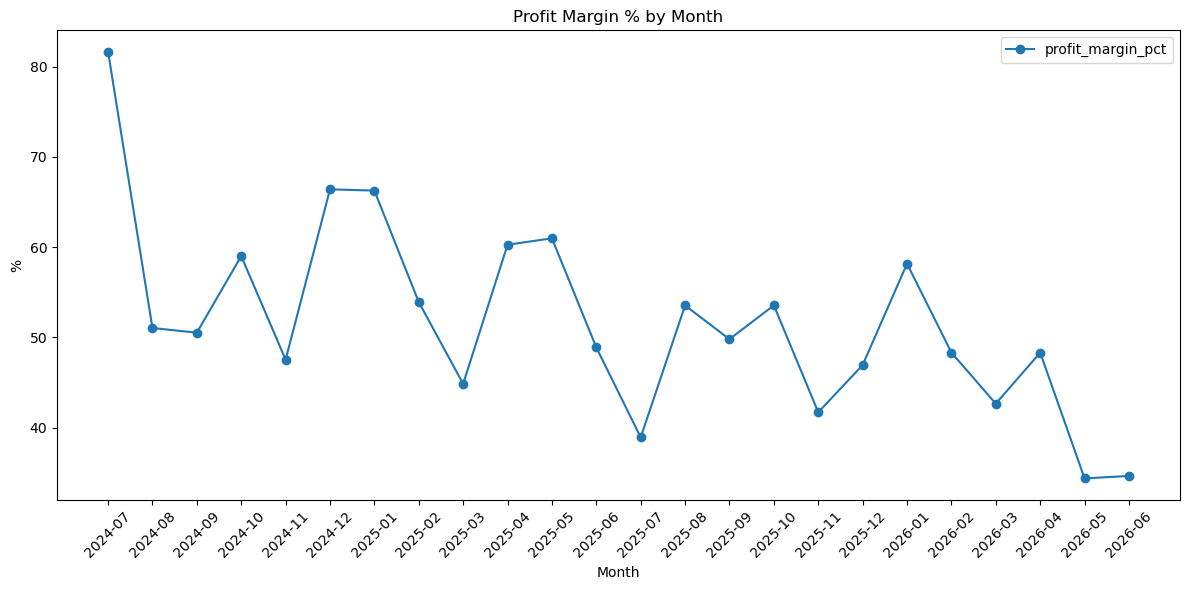

In [73]:
plt.figure(figsize=(12, 6))

plt.plot(
    by_month["year_month"].astype(str),
    by_month["profit_margin_pct"],
    marker="o",
    label="profit_margin_pct"
)



plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("%")
plt.title("Profit Margin % by Month")
plt.legend()
plt.tight_layout()
plt.show()

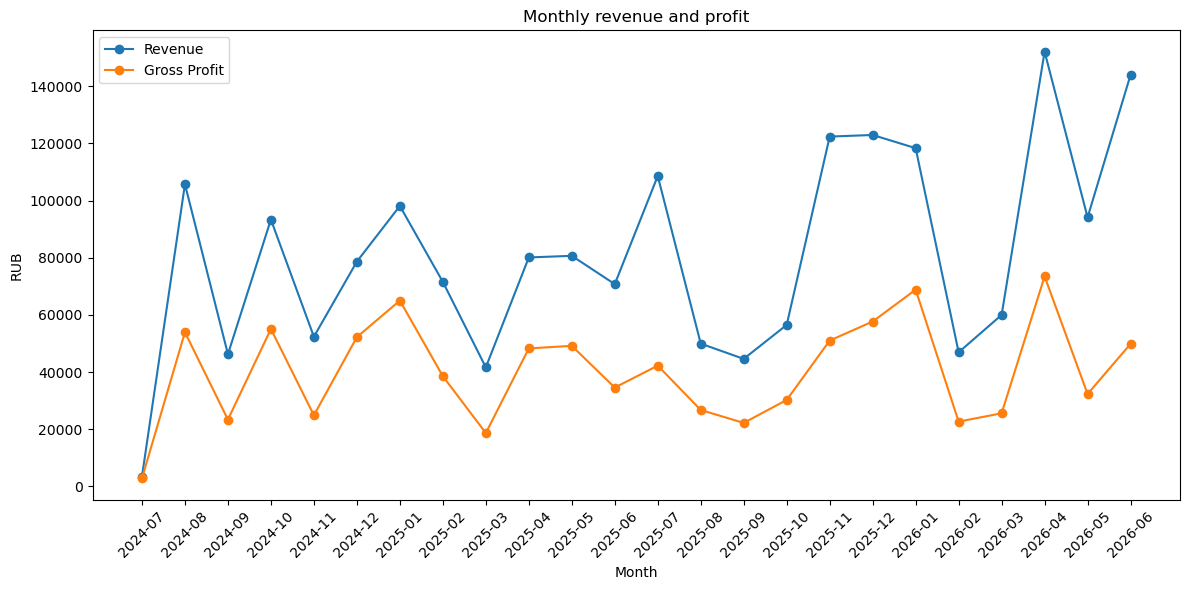

In [74]:
plt.figure(figsize=(12, 6))

plt.plot(
    by_month["year_month"].astype(str),
    by_month["revenue"],
    marker="o",
    label="Revenue"
)

plt.plot(
    by_month["year_month"].astype(str),
    by_month["gross_profit"],
    marker="o",
    label="Gross Profit"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("RUB")
plt.title("Monthly revenue and profit")
plt.legend()
plt.tight_layout()
plt.show()

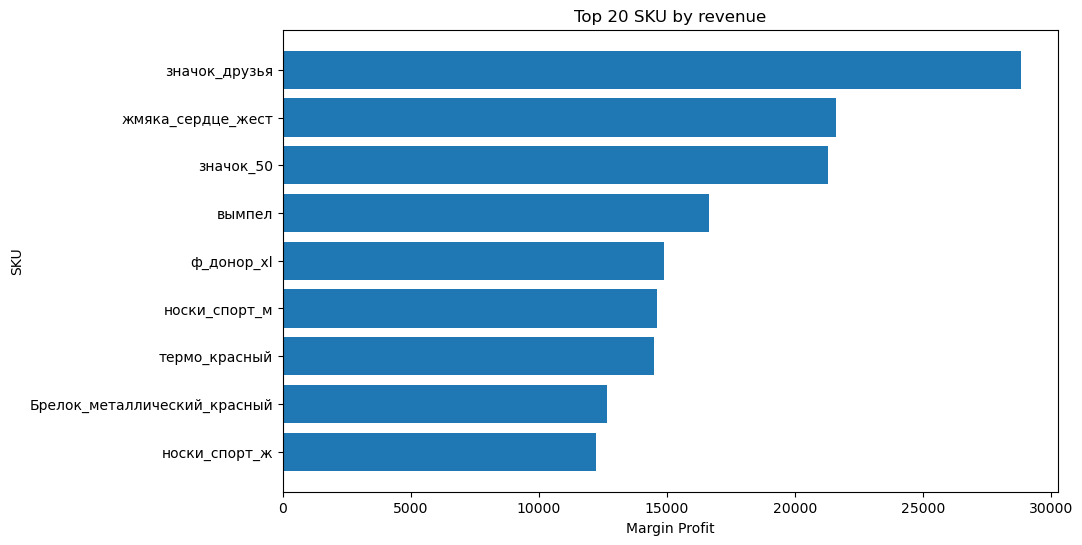

In [75]:
top20_revenue = (
    sales_fact
    .sort_values("revenue", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top20_revenue["sku"],
    top20_revenue["revenue"]
)

plt.xlabel("Margin Profit")
plt.ylabel("SKU")
plt.title("Top 20 SKU by revenue")

plt.gca().invert_yaxis()

plt.show()

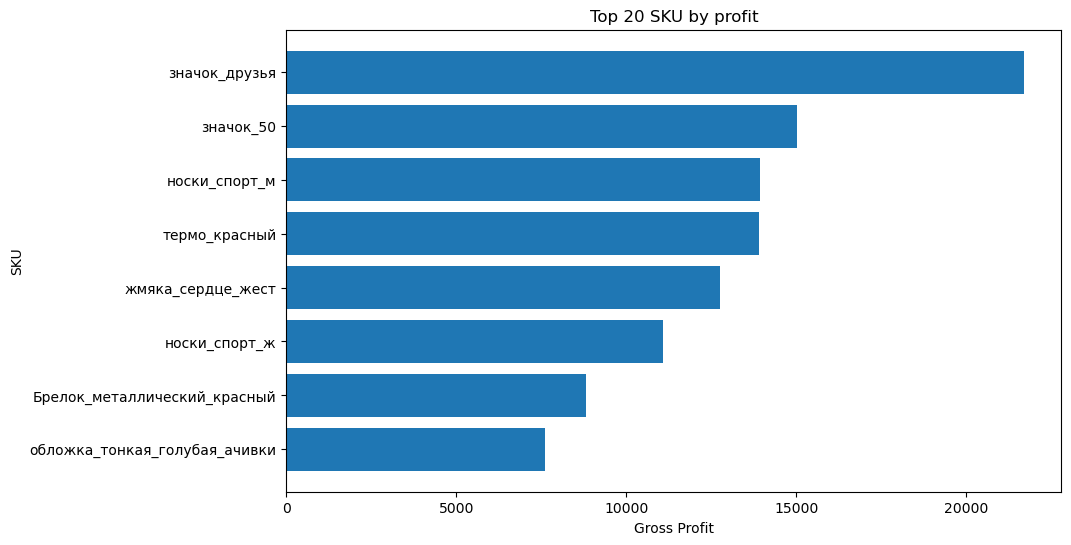

In [76]:
# 4.6 SKY by Profit
top20_profit = (
    sales_fact
    .sort_values("gross_profit", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top20_profit["sku"],
    top20_profit["gross_profit"]
)

plt.xlabel("Gross Profit")
plt.ylabel("SKU")
plt.title("Top 20 SKU by profit")

plt.gca().invert_yaxis()

plt.show()

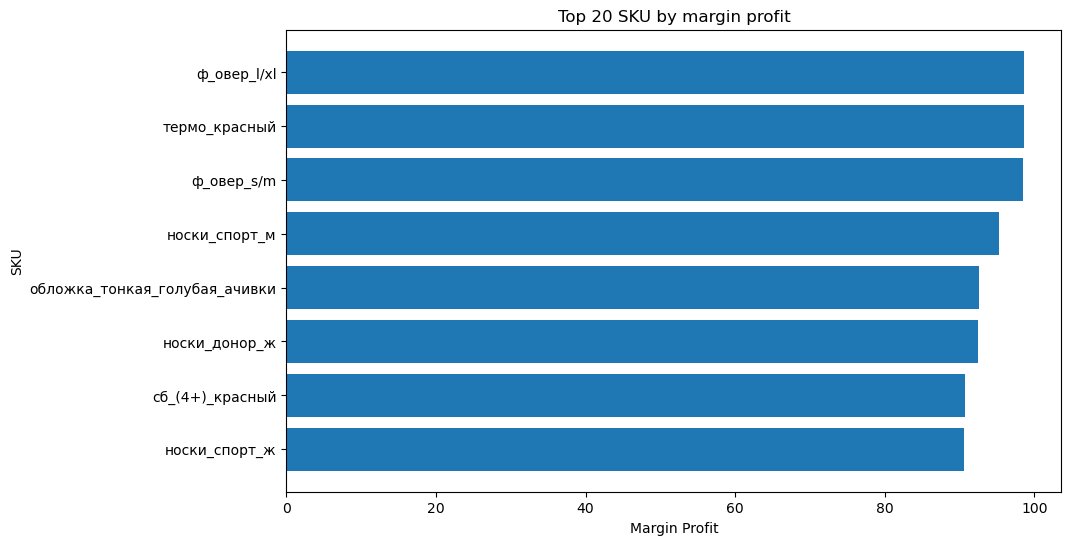

In [77]:

top20_margin_profit = (
    sales_fact
    .sort_values("margin_pct", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top20_margin_profit["sku"],
    top20_margin_profit["margin_pct"]
)

plt.xlabel("Margin Profit")
plt.ylabel("SKU")
plt.title("Top 20 SKU by margin profit")

plt.gca().invert_yaxis()

plt.show()

In [78]:
# 4.4.Cluster-Level Analysis
# At the cluster level, only inventory levels and inventory turnover are analyzed, 
# as revenue data is not available in the order reports.

by_cluster_stock = stock_cluster.groupby("Кластер").agg(
    stock_available=("Годный", "sum"),
    avg_turnover_days=("Оборачиваемость", "mean"),
    avg_daily_stock_l=("Среднесуточный объём товаров на складе, л", "sum"),
).reset_index()

by_cluster_stock

,Кластер,stock_available,avg_turnover_days,avg_daily_stock_l
0,Екатеринбург,89,52.000000,49.220
1,Москва,323,61.834783,241.679
2,Ростов,99,62.386957,43.185
3,Самара,293,67.607143,187.357
4,Санкт-Петербург,77,78.430000,74.366


## 5. SKU Segmentation: Sales × Margin Matrix

Products are segmented into four groups based on the median sales and median profit margin.

| Sales \\ Margin |	High Margin | Low Margin |
|---|---|---|
| **High Sales** |	Stars |	Volume Drivers |
| **Low Sales** |	Hidden Gems	|  Candidates for Discontinuation |




**Segmentation Notes**

* Stars – Products with high sales and high profit margins. These are the best-performing SKUs.
* Volume Drivers – Products with high sales but low profit margins. They generate sales volume but contribute less to profitability.
* Hidden Gems – Products with low sales but high profit margins. These products have growth potential and may benefit from increased promotion.
* Candidates for Discontinuation (Low-Priority Products) – Products with low sales and low profit margins. These SKUs may be considered for removal from the product portfolio.

In [79]:
sku_summary = by_sku[by_sku["revenue"] > 0].copy()
sku_summary["margin_pct"] = sku_summary["gross_profit"] / sku_summary["revenue"] * 100

sales_median = sku_summary["qty_delivered"].median()
margin_median = sku_summary["margin_pct"].median()


def get_segment(row):
    high_sales = row["qty_delivered"] >= sales_median
    high_margin = row["margin_pct"] >= margin_median
    if high_sales and high_margin:
        return "Stars"
    if high_sales and not high_margin:
        return "Volume Drivers"
    if not high_sales and high_margin:
        return "Hidden Gems"
    return "Candidates for Discontinuation"


sku_summary["segment"] = sku_summary.apply(get_segment, axis=1)

print(f"Sales median: {sales_median:.1f} units., margin median: {margin_median:.1f}%")
print(sku_summary["segment"].value_counts())
sku_summary.sort_values("gross_profit", ascending=False).head(10)


Sales median: 16.0 units., margin median: 45.1%
segment
Stars                             36
Candidates for Discontinuation    34
Volume Drivers                    18
Hidden Gems                       17
Name: count, dtype: int64


,sku,category,revenue,qty_delivered,gross_profit,margin_pct,segment
32,значок_50,Товары для дома · Товары для праздников · Дипл...,154296.0,158,104084.53,67.457698,Stars
30,жмяка_сердце_жест,Спорт и отдых · Тренажеры и фитнес · Фитнес · ...,159471.0,281,98950.29,62.049081,Stars
33,значок_друзья,Товары для дома · Товары для праздников · Дипл...,120324.0,124,78766.01,65.461595,Stars
89,термо_красный,Missing category,50415.0,50,48152.82,95.512883,Stars
31,жмяка_сердце_мяг,Спорт и отдых · Тренажеры и фитнес · Фитнес · ...,71179.0,125,43380.63,60.945827,Stars
11,Брелок_металлический_красный,"Одежда, обувь и аксессуары · Сумки и аксессуар...",42051.0,82,25990.25,61.806497,Stars
94,ф_бег_XL,"Одежда, обувь и аксессуары · Одежда для взросл...",42615.0,31,23401.17,54.912988,Stars
103,ф_овер_l/xl,Missing category,24354.0,22,22937.43,94.183420,Stars
91,ф_бег_L,"Одежда, обувь и аксессуары · Одежда для взросл...",43886.0,33,21877.51,49.850772,Stars
35,значок_друзья_набор,Товары для дома · Товары для праздников · Дипл...,36114.0,16,20495.60,56.752506,Stars


In [80]:
revenue_median = sku_summary["revenue"].median()

print("Revenue median:", revenue_median)
print("Margin median:", margin_median)

# Identifing SKU's with ----> High Revenue + Low Margin”
high_revenue_low_margin = sku_summary[
    (sku_summary["revenue"] >= revenue_median) &
    (sku_summary["margin_pct"] < margin_median)
].copy()

high_revenue_low_margin = high_revenue_low_margin.sort_values(
    "revenue",
    ascending=False
)
print("")
display(f"SKU with high Revenue and Low Margin",high_revenue_low_margin[
    ["sku", "revenue", "gross_profit", "margin_pct", "segment"]
])

Revenue median: 9231.0
Margin median: 45.13688032156286



'SKU with high Revenue and Low Margin'

,sku,revenue,gross_profit,margin_pct,segment
27,бутылка_650,83566.0,5157.32,6.171553,Volume Drivers
101,ф_донор_xl,56225.0,18049.47,32.102214,Volume Drivers
99,ф_донор_L,49940.0,13547.55,27.127653,Volume Drivers
28,вымпел,41599.0,10069.89,24.207048,Volume Drivers
24,Шапка,36636.0,11421.72,31.176220,Volume Drivers
102,ф_донор_м,32407.0,9871.36,30.460580,Volume Drivers
55,обложка_красная,30125.0,13494.26,44.794224,Volume Drivers
8,Бафф_красный,28101.0,7609.09,27.077648,Volume Drivers
106,шоппер_красный,23980.0,2831.33,11.807048,Volume Drivers
37,картхолдер,21651.0,3268.87,15.098009,Volume Drivers


In [81]:
# Hight Revenue + Hight Margin
high_revenue_high_margin = sku_summary[
    (sku_summary["revenue"] >= revenue_median) &
    (sku_summary["margin_pct"] >= margin_median)
].copy()

high_revenue_high_margin = high_revenue_high_margin.sort_values(
    "gross_profit",
    ascending=False
)
display(f"SKU with high Revenue and High Margin",high_revenue_high_margin[
    ["sku", "revenue", "gross_profit", "margin_pct", "segment"]
])

'SKU with high Revenue and High Margin'

,sku,revenue,gross_profit,margin_pct,segment
32,значок_50,154296.0,104084.53,67.457698,Stars
30,жмяка_сердце_жест,159471.0,98950.29,62.049081,Stars
33,значок_друзья,120324.0,78766.01,65.461595,Stars
89,термо_красный,50415.0,48152.82,95.512883,Stars
31,жмяка_сердце_мяг,71179.0,43380.63,60.945827,Stars
11,Брелок_металлический_красный,42051.0,25990.25,61.806497,Stars
94,ф_бег_XL,42615.0,23401.17,54.912988,Stars
103,ф_овер_l/xl,24354.0,22937.43,94.183420,Stars
91,ф_бег_L,43886.0,21877.51,49.850772,Stars
35,значок_друзья_набор,36114.0,20495.60,56.752506,Stars


In [82]:
hidden_gems = sku_summary[sku_summary["segment"]=="Hidden Gems"]
hidden_gems[["sku", "revenue", "gross_profit", "margin_pct", "qty_delivered"]].head(20)

,sku,revenue,gross_profit,margin_pct,qty_delivered
104,ф_овер_s/m,13197.0,12546.21,95.068652,10
95,ф_бег_XS,15057.0,6802.31,45.177061,13
12,Брелок_металлический_розовый,7870.0,4706.95,59.808767,15
36,значок_друзья_розовый,6782.0,4061.86,59.891772,8
76,сб_(4-)_красный,3941.0,3249.40,82.451155,14
98,ф_бег_XXXL,6773.0,3130.94,46.226783,6
63,ремувка_вышивка,5845.0,2949.20,50.456801,14
34,значок_друзья_голубой,4493.0,2451.70,54.567104,6
84,стикерпак_голубой,3319.0,2116.24,63.761374,15
68,сб_(2+)_белый,1960.0,1621.12,82.710204,6


In [83]:
sku_summary[
    [ "sku","revenue", "gross_profit", "margin_pct","segment"]
].sort_values(
    "revenue", ascending=False
).head(15)


,sku,revenue,gross_profit,margin_pct,segment
30,жмяка_сердце_жест,159471.0,98950.29,62.049081,Stars
32,значок_50,154296.0,104084.53,67.457698,Stars
33,значок_друзья,120324.0,78766.01,65.461595,Stars
27,бутылка_650,83566.0,5157.32,6.171553,Volume Drivers
31,жмяка_сердце_мяг,71179.0,43380.63,60.945827,Stars
101,ф_донор_xl,56225.0,18049.47,32.102214,Volume Drivers
89,термо_красный,50415.0,48152.82,95.512883,Stars
99,ф_донор_L,49940.0,13547.55,27.127653,Volume Drivers
91,ф_бег_L,43886.0,21877.51,49.850772,Stars
94,ф_бег_XL,42615.0,23401.17,54.912988,Stars


In [84]:
# sku below the 25th percentile margin_pct, will be considered sku with low margin_pct.
sku_summary["margin_pct"].describe()

count    105.000000
mean      46.058537
std       24.343110
min       -2.893203
25%       27.127653
50%       45.136880
75%       63.761374
max       95.512883
Name: margin_pct, dtype: float64

In [85]:
sku_summary[
    ["sku","margin_pct"]
].sort_values("margin_pct").head(10)

,sku,margin_pct
39,картхолдер_магнит_к,-2.893203
40,картхолдер_магнит_ч,2.909742
100,ф_донор_s,5.371190
27,бутылка_650,6.171553
3,heart_red_sm,9.601526
106,шоппер_красный,11.807048
88,термо_ds_красный,12.139407
7,smile_red_sm,12.773986
59,обложка_тонкая_розовая_ачивки,13.231884
37,картхолдер,15.098009


In [86]:
# Sort the table by margin, from lowest to highest
worst_product = sku_summary.sort_values(by="margin_pct", ascending=True).iloc[0]

worst_sku = worst_product["sku"]
worst_margin = round(worst_product["margin_pct"], 2)
worst_profit = round(worst_product["gross_profit"], 2)

print(f"The lowest profitability is for SKU {worst_sku} with a margin of {worst_margin}% (Total profit: {worst_profit} RUB.).")


The lowest profitability is for SKU картхолдер_магнит_к with a margin of -2.89% (Total profit: -227.29 RUB.).


In [87]:
# Sort the table by margin, from highest to lowest
best_product = sku_summary.sort_values(by="margin_pct", ascending=False).iloc[0]

best_sku = best_product["sku"]
best_margin = round(best_product["margin_pct"], 2)
best_profit = round(best_product["gross_profit"], 2)

print(f"The highest profitability is for SKU {best_sku} with a margin of {best_margin}% (Total profit: {worst_profit} RUB.).")


The highest profitability is for SKU термо_красный with a margin of 95.51% (Total profit: -227.29 RUB.).


In [88]:
# sales variability (Coefficient of Variation - CV) for each SKU across different months. 
# It helps identify products with unstable demand (large fluctuations in monthly sales).

#1. Create a monthly sales matrix
monthly_qty = sales_fact.pivot_table(
    index="sku", columns="year_month", values="qty_delivered", aggfunc="sum", fill_value=0
)
cv = (monthly_qty.std(axis=1) / monthly_qty.mean(axis=1).replace(0, np.nan)).rename("sales_cv")
sku_summary = sku_summary.merge(cv.reset_index(), on="sku", how="left")

print("SKU with unstable demand (large fluctuations in monthly sales):")
sku_summary.sort_values("sales_cv", ascending=False)[["sku", "qty_delivered", "sales_cv"]].head(10)



SKU with unstable demand (large fluctuations in monthly sales):


,sku,qty_delivered,sales_cv
99,Лонгслив_спортивный_XXL,1,4.898979
90,Лонгслив_спортивный_XXXL,1,4.898979
31,обложка_тонкая_голубая_ачивки,18,4.898979
84,свитшот_красный_M,1,4.898979
87,майка_S,2,4.898979
89,свитшот_красный_XL,1,4.898979
95,свитшот_красный_L,1,4.898979
98,носки_спортивные_красные_средние,5,4.898979
78,майка_L,4,4.898979
103,обложка_тонкая_розовая_ачивки,2,4.898979


In [89]:
display(monthly_qty)

year_month,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,...,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
sku,,,,,,,,,,,,,,,,,,,,,
heart_black_lxl,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,2
heart_black_sm,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
heart_red_lxl,0,0,0,0,0,0,0,0,0,0,...,1,0,4,0,0,0,0,0,0,0
heart_red_sm,0,0,0,0,0,0,0,0,0,0,...,1,1,1,0,0,0,0,1,0,0
smile_black_lxl,0,0,0,0,0,0,0,0,0,0,...,0,0,0,2,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ф_донор_м,0,3,6,3,1,1,3,5,1,0,...,0,0,0,1,1,0,2,0,0,0
ф_овер_l/xl,0,0,0,0,0,1,2,2,3,4,...,0,0,0,0,0,0,0,0,0,0
ф_овер_s/m,0,0,0,0,0,1,3,2,1,3,...,0,0,0,0,0,0,0,0,0,0


## 6. Price and Discount Analysis

Calculate the average price (weighted by quantity), discount share, and profit per unit for each SKU across the entire period.

In [90]:
# Calculate weighted average price and discount by SKU
# using all delivered orders together (not separately by month)

delivered_event = orders[orders["event_type"] == "delivered"].copy()

def weighted_price(group):
    qty_sum = group["quantity"].sum()
    if qty_sum == 0:
        return pd.Series({"avg_price_no_discount": 0, "avg_price_with_discount": 0})
    return pd.Series({
        "avg_price_no_discount": round((group["unit_price_with_vat_before_discount"] * group["quantity"]).sum() / qty_sum,2),
        "avg_price_with_discount": round((group["unit_price_with_vat_after_discount"] * group["quantity"]).sum() / qty_sum,2),
    })

price_by_sku = delivered_event.groupby("sku").apply(weighted_price).reset_index()

price_by_sku["discount_share_pct"] = np.where(
    price_by_sku["avg_price_no_discount"] > 0,
    (price_by_sku["avg_price_no_discount"] - price_by_sku["avg_price_with_discount"])
    / price_by_sku["avg_price_no_discount"] * 100,
    0,
).round(2)

# Add calculated prices and discount metrics to SKU summary table
sku_summary = sku_summary.merge(price_by_sku, on="sku", how="left")

# Calculate profit per delivered unit
# Contribution profit / number of delivered items
# If no items were delivered, set value to 0
sku_summary["profit_per_unit"] = np.where(
    sku_summary["qty_delivered"] > 0,
    sku_summary["gross_profit"] / sku_summary["qty_delivered"],
    0,
).round(2)

sku_summary.sort_values("discount_share_pct", ascending = False)[["sku", "qty_delivered", "avg_price_with_discount", "discount_share_pct", "profit_per_unit"]].head(15)


,sku,qty_delivered,avg_price_with_discount,discount_share_pct,profit_per_unit
103,обложка_тонкая_розовая_ачивки,2,241.50,53.82,31.96
92,Попсокет,29,84.00,41.07,19.33
49,обложка_толстая_красная_ачивки,16,708.19,37.85,233.00
104,картхолдер_магнит_к,20,392.80,35.99,-11.36
66,значок_друзья_голубой,6,748.83,35.19,408.62
88,стикерпак_желтый,8,196.00,34.14,110.46
78,майка_L,4,880.25,33.58,357.60
26,вымпел,79,526.57,31.38,127.47
47,значок_друзья_розовый,8,847.75,31.24,507.73
85,heart_red_sm,9,1296.33,29.80,124.47


In [91]:
print(sku_summary["discount_share_pct"].describe())


count    105.000000
mean      18.739905
std        8.658201
min        0.000000
25%       13.770000
50%       17.480000
75%       23.470000
max       53.820000
Name: discount_share_pct, dtype: float64


In [92]:
price_by_sku_month = (
    delivered_event
    .groupby(["sku", "year_month"])
    .apply(weighted_price)
    .reset_index()
)

price_by_sku_month["discount_share_pct_sku"] = np.where(
    price_by_sku_month["avg_price_no_discount"] > 0,
    (
        (price_by_sku_month["avg_price_no_discount"]
         - price_by_sku_month["avg_price_with_discount"])
        / price_by_sku_month["avg_price_no_discount"]
        * 100
    ),
    0
).round(2)

price_analysis = sales_fact.merge(
    price_by_sku_month,
    on=["sku", "year_month"],
    how="left"
)

price_analysis = price_analysis.sort_values(
    ["sku", "year_month"]
).copy()

price_analysis["price_change_pct"] = (
    price_analysis
    .groupby("sku")["avg_price_with_discount"]
    .pct_change()
    * 100
).round(2)

price_analysis["qty_change_pct"] = (
    price_analysis
    .groupby("sku")["qty_delivered"]
    .pct_change()
    * 100
).round(2)

price_analysis["profit_change_pct"] = (
    price_analysis
    .groupby("sku")["gross_profit"]
    .pct_change()
    * 100
).round(2)



In [93]:
# Analyze SKU performance over time
price_analysis[
    price_analysis["sku"] == "вымпел"
].sort_values("year_month")[
    [
        "sku",
        "year_month",
        "avg_price_with_discount",
        "discount_share_pct_sku",
        "qty_delivered",
        "revenue",
        "gross_profit",
        "price_change_pct",
        "qty_change_pct",
        "profit_change_pct"
    ]
]

,sku,year_month,avg_price_with_discount,discount_share_pct_sku,qty_delivered,revenue,gross_profit,price_change_pct,qty_change_pct,profit_change_pct
190,вымпел,2026-04,601.60,23.72,15,9024.0,2820.20,NaN,NaN,NaN
191,вымпел,2026-05,530.73,32.36,30,15922.0,4686.85,-11.78,100.00,66.19
192,вымпел,2026-06,489.79,34.05,34,16653.0,2562.84,-7.71,13.33,-45.32


In [94]:
# Find SKUs with high discounts and low sales.
# These are candidates for price optimization because the discount was ineffective.
candidates_for_price_review = sku_summary[
    (sku_summary["discount_share_pct"] > sku_summary["discount_share_pct"].median())
    & (sku_summary["segment"] == "Candidates for Discontinuation")
]
candidates_for_price_review.sort_values(by=["margin_pct", "qty_delivered"], ascending=[True, False])[["sku", "discount_share_pct", "qty_delivered", "margin_pct"]]

,sku,discount_share_pct,qty_delivered,margin_pct
102,картхолдер_магнит_ч,26.13,10,2.909742
85,heart_red_sm,29.80,9,9.601526
101,термо_ds_красный,26.12,3,12.139407
103,обложка_тонкая_розовая_ачивки,53.82,2,13.231884
71,smile_red_lxl,20.73,9,15.711326
82,Лонгслив_спортивный_M,28.71,6,16.493909
61,heart_red_lxl,18.91,10,18.669451
97,Стикерпаки_набор,27.29,10,19.635086
73,smile_black_lxl,18.72,6,21.265357
74,smile_black_sm,18.83,5,22.904565


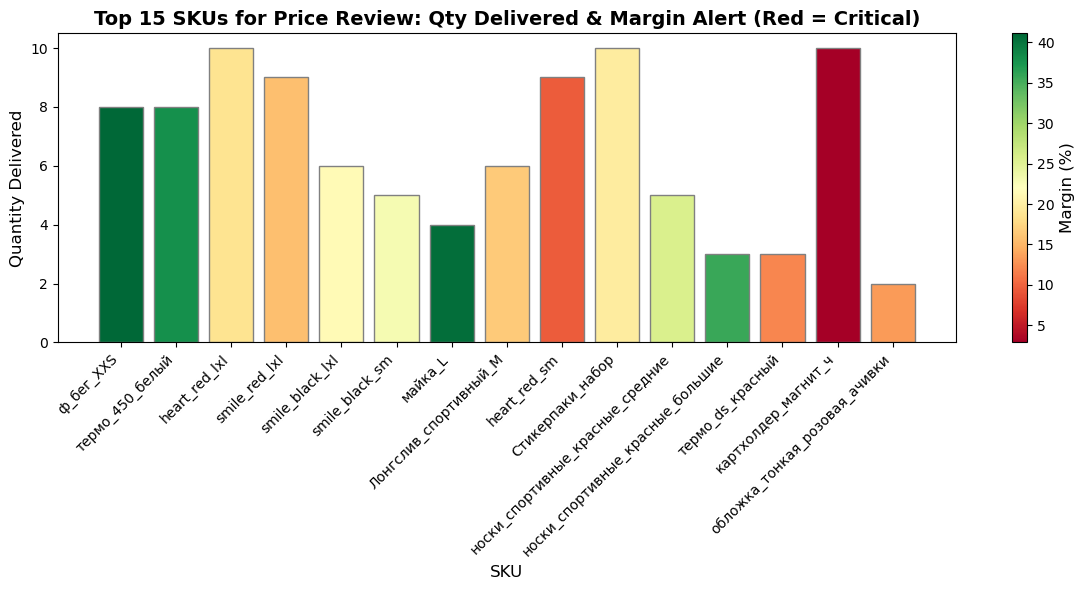

In [95]:
# Select the top 15 most problematic/important SKUs after sorting
top_candidates = candidates_for_price_review.head(15)

fig, ax = plt.subplots(figsize=(12, 6))

# Normalize colors based on margin (Red -> Yellow -> Green)
normalize = plt.Normalize(vmin=top_candidates["margin_pct"].min(), vmax=top_candidates["margin_pct"].max())
cmap = plt.get_cmap("RdYlGn")
colors = cmap(normalize(top_candidates["margin_pct"].values))

# Plot bars for Quantity
bars = ax.bar(top_candidates["sku"], top_candidates["qty_delivered"], color=colors, edgecolor="grey")

# English Labels and Titles
ax.set_title("Top 15 SKUs for Price Review: Qty Delivered & Margin Alert (Red = Critical)", fontsize=14, fontweight="bold")
ax.set_xlabel("SKU", fontsize=12)
ax.set_ylabel("Quantity Delivered", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Add a colorbar to explain the bar colors
sm = plt.cm.ScalarMappable(cmap=cmap, norm=normalize)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Margin (%)", fontsize=12)

plt.tight_layout()
plt.show()


## 7. Sales funnel analysis without advertising data.
Since advertising costs are not included in the available datasets,the analysis evaluates only the natural conversion performance:
* impressions → add to cart → orders → delivered orders.

In [96]:
funnel_analysis = funnel_sku.merge(sku_category, on="sku", how="left")
funnel_analysis["cart_rate_pct"] = np.where(
    funnel_analysis["impressions"] > 0,
    funnel_analysis["cart_adds"] / funnel_analysis["impressions"] * 100,
    0,
)

print("Average impression-to-cart conversion rate: {:.2f}%".format(
    funnel_analysis["cart_rate_pct"].replace(0, np.nan).mean()))
print("Average cart-to-order conversion rate: {:.2f}%".format(
    funnel_analysis["cart_conversion_pct"].replace(0, np.nan).mean()))

funnel_analysis.sort_values("impressions", ascending=False)[
    ["sku", "category", "impressions", "cart_adds", "ordered_qty", "cart_conversion_pct"]
].head(10)

Average impression-to-cart conversion rate: 0.75%
Average cart-to-order conversion rate: 27.01%


,sku,category,impressions,cart_adds,ordered_qty,cart_conversion_pct
91,сб_(2+)_красный,"Одежда, обувь и аксессуары · Сумки и аксессуар...",60968.0,106.0,34.0,32.075472
76,обложка_красная,"Одежда, обувь и аксессуары · Сумки и аксессуар...",51381.0,199.0,64.0,32.160804
48,жмяка_сердце_мяг,Спорт и отдых · Тренажеры и фитнес · Фитнес · ...,47577.0,310.0,119.0,38.387097
54,картхолдер,"Одежда, обувь и аксессуары · Сумки и аксессуар...",46063.0,141.0,32.0,22.695035
44,бутылка_650,Товары для дома · Посуда и кухонные принадлежн...,41912.0,180.0,47.0,26.111111
129,шоппер_красный,"Одежда, обувь и аксессуары · Сумки и аксессуар...",41783.0,171.0,29.0,16.959064
39,Шапка,"Одежда, обувь и аксессуары · Аксессуары · Голо...",40997.0,246.0,47.0,19.105691
47,жмяка_сердце_жест,Спорт и отдых · Тренажеры и фитнес · Фитнес · ...,40757.0,293.0,97.0,33.105802
26,Бутылка_алюминиевая,Товары для дома · Посуда и кухонные принадлежн...,40393.0,136.0,19.0,13.970588
78,обложка_тонкая,"Одежда, обувь и аксессуары · Сумки и аксессуар...",40317.0,103.0,30.0,29.126214


## 8. Profit Loss Analysis

 * Estimate profit losses from four main sources:
 
 - Out-of-stock (OOS) products: items currently unavailable but with recent sales,assuming stock shortages continue for the next `LOSS_PROJECTION_DAYS`.
- Excess inventory: products with inventory turnover exceeding `EXCESS_TURNOVER_DAYS`.(Inventory Turnover: The speed at which a business sells and replaces its stock of goods)
- Returns: lost contribution margin from returned products.
- Undelivered / unclaimed orders: lost contribution margin from orders that were not completed by customers.

### Note:
Historical inventory data is not available.Therefore, OOS losses are estimated using the current inventory snapshot and a forward-looking projection.

## Data quality check:
Before estimating losses, validate the inventory report metrics.Compare the "30-day Sales" field from the inventory report with the average monthly sales calculated independently from completed orders.This verification helps identify inconsistencies between different source reports before performing the analysis.

In [97]:
# Compare "30-day sales" from the inventory report with sales calculated from order data.
avg_monthly_qty_orders = (
    sales_fact[sales_fact["qty_delivered"] > 0]
    .groupby("sku")["qty_delivered"].mean()
    .rename("avg_monthly_qty_orders")
)

anomaly_check = stock_sku[["sku", "sales_30d"]].merge(
    avg_monthly_qty_orders.reset_index(), on="sku", how="left"
).fillna(0)
anomaly_check["ratio"] = np.where(
    anomaly_check["avg_monthly_qty_orders"] > 0,
    anomaly_check["sales_30d"] / anomaly_check["avg_monthly_qty_orders"],
    np.nan,
)

print("Top 10 SKUs with the largest discrepancy between inventory report sales and calculated order-based sales:")
display(anomaly_check.sort_values("ratio", ascending=False).head(10))
print()
print("Conclusion:")
print("The 'Sales 30d' metric from the inventory report shows significant discrepancies compared with delivered")
print("quantities calculated from order data.")
print("Therefore, this metric is considered unreliable for further calculations.")
print("For inventory analysis, we use the validated order-based metric: avg_monthly_qty_orders.")

Top 10 SKUs with the largest discrepancy between inventory report sales and calculated order-based sales:


,sku,sales_30d,avg_monthly_qty_orders,ratio
39,значок_друзья_набор,11636.0,2.285714,5090.750000
36,значок_50,21535.0,8.315789,2589.651899
91,свитшот_красный_L,2554.0,1.000000,2554.000000
108,ф_бег_S,3842.0,1.714286,2241.166667
38,значок_друзья_голубой,3113.0,1.500000,2075.333333
93,свитшот_красный_S,2940.0,1.500000,1960.000000
7,smile_red_sm,2617.0,1.500000,1744.666667
40,значок_друзья_розовый,2126.0,1.333333,1594.500000
31,бутылка_650,8509.0,6.476190,1313.889706
48,майка_S,2484.0,2.000000,1242.000000



Conclusion:
The 'Sales 30d' metric from the inventory report shows significant discrepancies compared with delivered
quantities calculated from order data.
Therefore, this metric is considered unreliable for further calculations.
For inventory analysis, we use the validated order-based metric: avg_monthly_qty_orders.


In [98]:
avg_monthly_qty_orders.sort_values(ascending = False).head()

sku
вымпел                           26.333333
обложка_тонкая_голубая_ачивки    18.000000
жмяка_сердце_жест                12.772727
носки_спорт_м                    12.000000
стикерпак_3д_2_стикера           11.333333
Name: avg_monthly_qty_orders, dtype: float64

In [99]:
# Current stock shortage (OOS)
# Use average monthly sales calculated from verified order data.

oos_now = stock_cluster[
    stock_cluster["Годный"] == 0
][["sku", "Кластер"]].copy()

oos_now = oos_now.merge(
    avg_monthly_qty_orders.reset_index(),
    on="sku",
    how="left"
).fillna(0)

# Keep only SKUs with recent sales
oos_now = oos_now[
    oos_now["avg_monthly_qty_orders"] > 0
]

# Convert average monthly sales into average daily sales
oos_now["avg_daily_units"] = (
    oos_now["avg_monthly_qty_orders"] / 30
).round(2)

# Add profit per unit calculated from revenue, COGS and marketplace fees
oos_now = oos_now.merge(
    sku_summary[["sku", "profit_per_unit"]],
    on="sku",
    how="left"
).fillna({"profit_per_unit": 0})

# Estimate lost profit if the stock shortage continues
# for the next LOSS_PROJECTION_DAYS (30 days)
oos_now["lost_profit_projected"] = (
    oos_now["avg_daily_units"]
    * oos_now["profit_per_unit"]
    * LOSS_PROJECTION_DAYS
).round(2)

total_oos_loss = oos_now["lost_profit_projected"].sum()
print(f"SKU x cluster with current stock shortage(deficit) and recent sales: {len(oos_now)}")
print(f"Estimated profit loss for {LOSS_PROJECTION_DAYS} days if the shortage is not resolved: "
      f"{total_oos_loss:,.0f} RUB.")
oos_now.sort_values("lost_profit_projected", ascending=False)[
    ["sku", "Кластер", "avg_daily_units", "lost_profit_projected"]
].head(20)

SKU x cluster with current stock shortage(deficit) and recent sales: 188
Estimated profit loss for 30 days if the shortage is not resolved: 244,404 RUB.


,sku,Кластер,avg_daily_units,lost_profit_projected
38,термо_красный,Екатеринбург,0.28,8089.70
70,термо_красный,Москва,0.28,8089.70
39,термо_красный,Самара,0.28,8089.70
66,обложка_тонкая_голубая_ачивки,Екатеринбург,0.60,7615.26
8,значок_50,Санкт-Петербург,0.28,5533.58
10,значок_50,Самара,0.28,5533.58
12,значок_50,Москва,0.28,5533.58
13,значок_50,Ростов,0.28,5533.58
133,значок_друзья,Москва,0.21,4001.82
134,значок_друзья,Санкт-Петербург,0.21,4001.82


In [100]:
# Identify the sku's that have OOS in at least one cluster
oos_now = stock_cluster[stock_cluster["Годный"] == 0][["sku", "Кластер"]].copy()

oos_now = oos_now.merge(
    avg_monthly_qty_orders.reset_index(),
    on="sku",
    how="left"
).fillna(0)

oos_now = oos_now[oos_now["avg_monthly_qty_orders"] > 0]

oos_now["avg_daily_units"] = oos_now["avg_monthly_qty_orders"] / 30

oos_now = oos_now.merge(
    sku_summary[["sku", "profit_per_unit"]],
    on="sku",
    how="left"
).fillna({"profit_per_unit": 0})

oos_now["lost_profit_projected"] = (
    oos_now["avg_daily_units"]
    * oos_now["profit_per_unit"]
    * LOSS_PROJECTION_DAYS
)

total_oos_loss = oos_now["lost_profit_projected"].sum()
print(f"SKU x cluster with current stock shortage(deficit) and recent sales: {len(oos_now)}")
print(f"Estimated profit loss for{LOSS_PROJECTION_DAYS} days if the shortage is not resolved: "
      f"{total_oos_loss:,.0f} RUB.")
oos_now.sort_values("lost_profit_projected", ascending=False)[
    ["sku", "avg_daily_units", "lost_profit_projected"]
].head(20)

SKU x cluster with current stock shortage(deficit) and recent sales: 188
Estimated profit loss for30 days if the shortage is not resolved: 243,572 RUB.


,sku,avg_daily_units,lost_profit_projected
38,термо_красный,0.277778,8025.500000
39,термо_красный,0.277778,8025.500000
70,термо_красный,0.277778,8025.500000
66,обложка_тонкая_голубая_ачивки,0.600000,7615.260000
8,значок_50,0.277193,5478.109474
12,значок_50,0.277193,5478.109474
10,значок_50,0.277193,5478.109474
13,значок_50,0.277193,5478.109474
68,носки_спорт_м,0.400000,3979.560000
67,носки_спорт_м,0.400000,3979.560000


In [101]:
# Select SKU with stock = 0
oos_skus = stock_cluster.loc[
    stock_cluster["Годный"] == 0,
    "sku"
].drop_duplicates()

oos_now = pd.DataFrame({
    "sku": oos_skus
})

In [102]:
oos_now.head()

,sku
1,стикерпак_3D
8,майка_S
9,свитшот_красный_S
12,Лонслив_спортивный_S
14,носки_донор_ж


In [103]:
# 8.3-8.4. Lost profit from returns and undelivered orders

sales_fact["contribution_margin_share"] = (
    sales_fact["revenue_with_discount"]
    - sales_fact["cogs"]
    - sales_fact["marketplace_fee"]
) / sales_fact["revenue_with_discount"]

sales_fact["lost_profit_returns"] = (
    sales_fact["returned_revenues_with_discount"]
    * sales_fact["contribution_margin_share"]
)

sales_fact["lost_profit_not_purchased"] = (
    sales_fact["undelivered_revenue_with_discount"]
    * sales_fact["contribution_margin_share"]
)

total_returns_amount = sales_fact["returned_revenues_with_discount"].sum()
total_not_purchased_amount = sales_fact["undelivered_revenue_with_discount"].sum()

total_lost_profit_returns = sales_fact["lost_profit_returns"].sum()
total_lost_profit_not_purchased = sales_fact["lost_profit_not_purchased"].sum()

print(
    f"Total returns: {total_returns_amount:,.0f} RUB -> "
    f"lost profit: {total_lost_profit_returns:,.0f} RUB"
)

print(
    f"Total undelivered orders: {total_not_purchased_amount:,.0f} RUB -> "
    f"lost profit: {total_lost_profit_not_purchased:,.0f} RUB"
)

Total returns: 19,273 RUB -> lost profit: 7,369 RUB
Total undelivered orders: 152,895 RUB -> lost profit: -261,865 RUB


In [104]:
losses_summary = pd.DataFrame({
    "loss_source": [
        "Current stock shortage (OOS)",
        "Returns",
        "Undelivered orders"
    ],
    "lost_profit_rub": [
        total_oos_loss,
        total_lost_profit_returns,
        total_lost_profit_not_purchased
    ],
})

losses_summary["lost_profit_rub"] = (
    losses_summary["lost_profit_rub"].round(0)
)

losses_summary

,loss_source,lost_profit_rub
0,Current stock shortage (OOS),243572.0
1,Returns,7369.0
2,Undelivered orders,-261865.0


In [105]:
sales_fact.head()

,sku,year_month,qty_delivered,qty_in_transit,qty_returned,qty_undelivered,revenue_with_discount,revenue_no_discount,cogs_share,marketplace_fee,...,avg_daily_stock_l,turnover_days,restock_recommended,revenue,cogs,gross_profit,margin_pct,contribution_margin_share,lost_profit_returns,lost_profit_not_purchased
0,heart_black_lxl,2025-07,4,5,0,1,6845.0,7960.0,4400.0,708.65,...,0.000,0.0,0.0,6845.0,4400.0,1736.35,25.37,0.253667,0.0,328.752316
1,heart_black_lxl,2025-12,1,1,0,0,1616.0,1990.0,1100.0,30.41,...,0.000,0.0,0.0,1616.0,1100.0,485.59,30.05,0.300489,0.0,0.000000
2,heart_black_lxl,2026-05,1,2,0,0,767.0,1401.0,1100.0,22.68,...,0.000,0.0,0.0,767.0,1100.0,-355.68,-46.37,-0.463729,-0.0,-0.000000
3,heart_black_lxl,2026-06,2,1,0,0,2697.0,2980.0,2200.0,48.22,...,0.000,0.0,0.0,2697.0,2200.0,448.78,16.64,0.166400,0.0,0.000000
4,heart_black_sm,2025-07,2,2,0,0,3343.0,3980.0,2200.0,235.74,...,5.022,0.0,0.0,3343.0,2200.0,907.26,27.14,0.271391,0.0,0.000000


In [106]:
sku_summary.head()

,sku,category,revenue,qty_delivered,gross_profit,margin_pct,segment,sales_cv,avg_price_no_discount,avg_price_with_discount,discount_share_pct,profit_per_unit
0,значок_50,Товары для дома · Товары для праздников · Дипл...,154296.0,158,104084.53,67.457698,Stars,0.941619,1232.44,976.56,20.76,658.76
1,жмяка_сердце_жест,Спорт и отдых · Тренажеры и фитнес · Фитнес · ...,159471.0,281,98950.29,62.049081,Stars,0.989158,667.82,567.51,15.02,352.14
2,значок_друзья,Товары для дома · Товары для праздников · Дипл...,120324.0,124,78766.01,65.461595,Stars,1.173383,1123.40,970.35,13.62,635.21
3,термо_красный,Missing category,50415.0,50,48152.82,95.512883,Stars,2.150899,1196.64,1008.30,15.74,963.06
4,жмяка_сердце_мяг,Спорт и отдых · Тренажеры и фитнес · Фитнес · ...,71179.0,125,43380.63,60.945827,Stars,0.993603,704.36,569.43,19.16,347.05


In [107]:
losses_summary.head()

,loss_source,lost_profit_rub
0,Current stock shortage (OOS),243572.0
1,Returns,7369.0
2,Undelivered orders,-261865.0


In [108]:
transactions_sheet = "Транзакции по заказам и товарам"

all_transactions = []

for file_path in orders_files:

    xls = pd.ExcelFile(file_path)

    if transactions_sheet in xls.sheet_names:

        df = pd.read_excel(
            xls,
            sheet_name=transactions_sheet,
            header=8
        )
        
        df = df.iloc[1:].reset_index(drop=True)

        all_transactions.append(df)

print(f"Files found: {len(all_transactions)} ")

/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/

Files found: 24 


/Users/sweetyolo/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [109]:
transactions = pd.concat(all_transactions, ignore_index=True)

print(transactions.shape)
transactions.head()


(6063, 77)


,ID бизнес-аккаунта,Модели работы,ID магазинов,Названия магазинов,ИНН,Номера договоров на размещение,Номера договоров на продвижение,Номер заказа,Ваш номер заказа,Дата оформления,...,Сумма возврата.3,Номер платежного поручения.7,Дата платежного поручения.7,Идентификатор платежа.7,Дата реестра платежей.7,Удержанная сумма,Номер платежного поручения.8,Дата платежного поручения.8,Идентификатор платежа.8,Дата реестра платежей.8
0,123729115.0,FBY,123729110.0,DonorSearch Shop - Магазин сообщества доноров,1.686035e+09,12104779/24,ОФ-8637971,566020977.0,566020977.0,15.10.2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,123729115.0,FBY,123729110.0,DonorSearch Shop - Магазин сообщества доноров,1.686035e+09,12104779/24,ОФ-8637971,566020977.0,566020977.0,15.10.2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,123729115.0,FBY,123729110.0,DonorSearch Shop - Магазин сообщества доноров,1.686035e+09,12104779/24,ОФ-8637971,560570400.0,560570400.0,08.10.2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,123729115.0,FBY,123729110.0,DonorSearch Shop - Магазин сообщества доноров,1.686035e+09,12104779/24,ОФ-8637971,552240545.0,552240545.0,25.09.2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,123729115.0,FBY,123729110.0,DonorSearch Shop - Магазин сообщества доноров,1.686035e+09,12104779/24,ОФ-8637971,570748855.0,570748855.0,22.10.2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [110]:
transactions_df = transactions[
    ["Номер заказа",
      "Дата оформления",
      "Ваш SKU",
      "Название товара",
      "Цена продажи (за шт.), ₽",
      "Другие скидки Маркета (за шт.), ₽",
      "Передано в доставку",
      "Доставлено или возвращено",
      "Дата доставки заказа",
      "Статус товара",
      "Регион доставки",
      "Сумма платежа",
      ]
].copy()

In [111]:
transactions_df.head()

,Номер заказа,Дата оформления,Ваш SKU,Название товара,"Цена продажи (за шт.), ₽","Другие скидки Маркета (за шт.), ₽",Передано в доставку,Доставлено или возвращено,Дата доставки заказа,Статус товара,Регион доставки,Сумма платежа
0,566020977.0,15.10.2024,жмяка_сердце_жест,"Кистевой эспандер DonorSearch ""Жмяка""",701.0,31.0,1.0,1.0,20.10.2024,Доставлен покупателю,Северодвинск,658.0
1,566020977.0,15.10.2024,бутылка_650,Питьевая бутылка DonorSearch,950.0,0.0,1.0,1.0,20.10.2024,Доставлен покупателю,Северодвинск,934.0
2,560570400.0,08.10.2024,значок_друзья,Значок DonorSearch,1126.0,0.0,7.0,7.0,10.10.2024,Доставлен покупателю,Саратов,7882.0
3,552240545.0,25.09.2024,жмяка_сердце_жест,Кистевой эспандер Жмяка DonorSearch,730.0,94.0,1.0,1.0,NaN,Невыкуп принят на складе,Апрелевка,NaN
4,570748855.0,22.10.2024,ф_донор_L,"Футболка ""Донор крови, донор жизни!"", L",1315.0,0.0,1.0,1.0,26.10.2024,Доставлен покупателю,Чебоксары,1315.0


In [112]:
transactions_df.rename(columns={"Ваш SKU" : "SKU",
                       "Номер заказа" : "number_of_order",
                       "Название товара" : "product_name",
                       "Дата оформления" : "order_date",
                       "Цена продажи (за шт.), ₽" : "sale_price",
      "Другие скидки Маркета (за шт.), ₽" : "market_discount",
      "Передано в доставку" : "quantity_shipped",
      "Доставлено или возвращено" : "quantity_delivered_or_returned",
      "Дата доставки заказа" : "delivery_date",
      "Статус товара" : "item_status",
      "Регион доставки" : "delivery_region",
      "Сумма платежа" : "payment_amount",
},inplace=True)

In [113]:
display(transactions_df.head())

,number_of_order,order_date,SKU,product_name,sale_price,market_discount,quantity_shipped,quantity_delivered_or_returned,delivery_date,item_status,delivery_region,payment_amount
0,566020977.0,15.10.2024,жмяка_сердце_жест,"Кистевой эспандер DonorSearch ""Жмяка""",701.0,31.0,1.0,1.0,20.10.2024,Доставлен покупателю,Северодвинск,658.0
1,566020977.0,15.10.2024,бутылка_650,Питьевая бутылка DonorSearch,950.0,0.0,1.0,1.0,20.10.2024,Доставлен покупателю,Северодвинск,934.0
2,560570400.0,08.10.2024,значок_друзья,Значок DonorSearch,1126.0,0.0,7.0,7.0,10.10.2024,Доставлен покупателю,Саратов,7882.0
3,552240545.0,25.09.2024,жмяка_сердце_жест,Кистевой эспандер Жмяка DonorSearch,730.0,94.0,1.0,1.0,NaN,Невыкуп принят на складе,Апрелевка,NaN
4,570748855.0,22.10.2024,ф_донор_L,"Футболка ""Донор крови, донор жизни!"", L",1315.0,0.0,1.0,1.0,26.10.2024,Доставлен покупателю,Чебоксары,1315.0


In [114]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6063 entries, 0 to 6062
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   number_of_order                 6063 non-null   float64
 1   order_date                      6063 non-null   object 
 2   SKU                             6063 non-null   object 
 3   product_name                    6063 non-null   object 
 4   sale_price                      6063 non-null   float64
 5   market_discount                 6063 non-null   float64
 6   quantity_shipped                5837 non-null   float64
 7   quantity_delivered_or_returned  6063 non-null   float64
 8   delivery_date                   5558 non-null   object 
 9   item_status                     6063 non-null   object 
 10  delivery_region                 6063 non-null   object 
 11  payment_amount                  5720 non-null   float64
dtypes: float64(6), object(6)
memory us

In [115]:
transactions_df[transactions_df["quantity_shipped"].isna()][["order_date","item_status", "quantity_shipped", "quantity_delivered_or_returned"]
].head(20)

,order_date,item_status,quantity_shipped,quantity_delivered_or_returned
70,31.10.2024,Отменён,NaN,1.0
78,26.10.2024,Отменён,NaN,1.0
107,25.10.2024,Отменён,NaN,1.0
121,02.10.2024,Отменён,NaN,1.0
165,26.10.2024,Отменён,NaN,1.0
199,23.03.2026,Отменён,NaN,3.0
200,25.03.2026,Отменён,NaN,1.0
235,05.03.2026,Отменён,NaN,1.0
239,26.03.2026,Отменён,NaN,2.0
265,18.03.2026,Отменён,NaN,1.0


In [116]:
transactions_df["number_of_order"] = transactions_df["number_of_order"].astype("Int64").astype(str)
#astype("Int64")   # elimină .0
    
transactions_df["quantity_shipped"] = transactions_df["quantity_shipped"].fillna(0).astype("int")
transactions_df["quantity_delivered_or_returned"] = transactions_df["quantity_delivered_or_returned"].astype("int")

transactions_df["order_date"] = pd.to_datetime(transactions_df["order_date"],
                                               format = "%d.%m.%Y",
                                                   errors = "coerce")
transactions_df["delivery_date"] = pd.to_datetime(transactions_df["delivery_date"],
                                                  format = "%d.%m.%Y",
                                                  errors = "coerce")

In [117]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6063 entries, 0 to 6062
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   number_of_order                 6063 non-null   object        
 1   order_date                      6063 non-null   datetime64[ns]
 2   SKU                             6063 non-null   object        
 3   product_name                    6063 non-null   object        
 4   sale_price                      6063 non-null   float64       
 5   market_discount                 6063 non-null   float64       
 6   quantity_shipped                6063 non-null   int64         
 7   quantity_delivered_or_returned  6063 non-null   int64         
 8   delivery_date                   5558 non-null   datetime64[ns]
 9   item_status                     6063 non-null   object        
 10  delivery_region                 6063 non-null   object        
 11  paym

In [118]:
transactions_df.head()

,number_of_order,order_date,SKU,product_name,sale_price,market_discount,quantity_shipped,quantity_delivered_or_returned,delivery_date,item_status,delivery_region,payment_amount
0,566020977,2024-10-15,жмяка_сердце_жест,"Кистевой эспандер DonorSearch ""Жмяка""",701.0,31.0,1,1,2024-10-20,Доставлен покупателю,Северодвинск,658.0
1,566020977,2024-10-15,бутылка_650,Питьевая бутылка DonorSearch,950.0,0.0,1,1,2024-10-20,Доставлен покупателю,Северодвинск,934.0
2,560570400,2024-10-08,значок_друзья,Значок DonorSearch,1126.0,0.0,7,7,2024-10-10,Доставлен покупателю,Саратов,7882.0
3,552240545,2024-09-25,жмяка_сердце_жест,Кистевой эспандер Жмяка DonorSearch,730.0,94.0,1,1,NaT,Невыкуп принят на складе,Апрелевка,NaN
4,570748855,2024-10-22,ф_донор_L,"Футболка ""Донор крови, донор жизни!"", L",1315.0,0.0,1,1,2024-10-26,Доставлен покупателю,Чебоксары,1315.0


In [119]:
transactions_df.duplicated().sum()

2797

In [120]:
city_delivery = transactions_df.groupby("delivery_region")["delivery_region"].value_counts().sort_values(ascending = False).head(10)
city_delivery


delivery_region
Москва             1123
Санкт-Петербург     414
Казань              206
Екатеринбург        185
Самара              181
Челябинск           159
Нижний Новгород     136
Уфа                 107
Ростов-на-Дону       98
Новосибирск          95
Name: count, dtype: int64

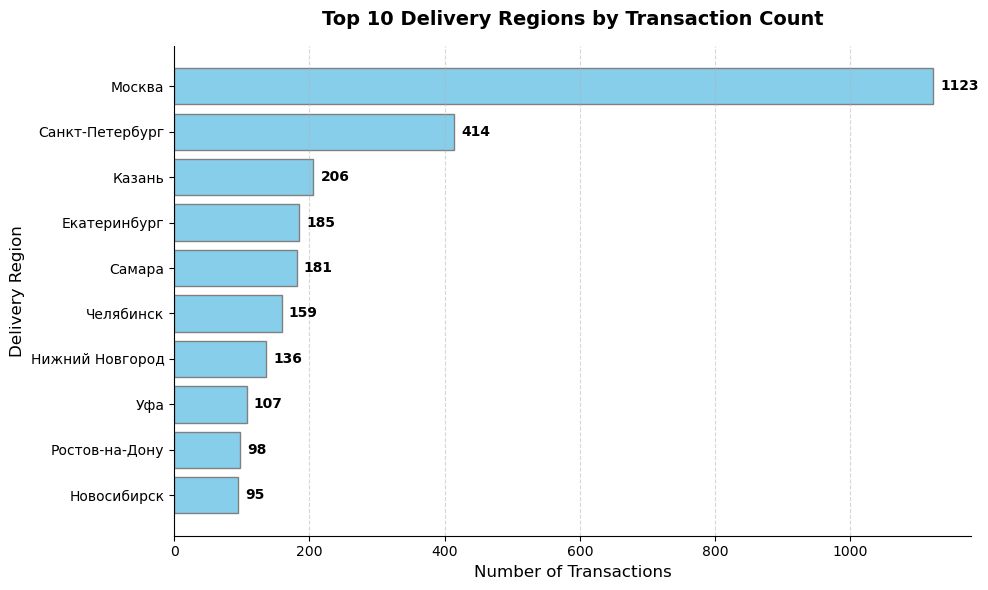

In [125]:
fig, ax = plt.subplots(figsize=(10, 6))

#groupby + value_counts returns - MultiIndex. 
cities = [str(index[-1] if isinstance(index, tuple) else index) for index in city_delivery.index]
counts = city_delivery.values

# horizontal bar(I use .invert_yaxis() that the biggest city to be first)
bars = ax.barh(cities, counts, color="skyblue", edgecolor="grey")
ax.invert_yaxis()  # Top 1 will be fisrt position
# # Add labels with the exact number of deliveries at the end of each bar
ax.bar_label(bars, padding=5, fontsize=10, fontweight="bold")

# Titluri și etichete în engleză
ax.set_title("Top 10 Delivery Regions by Transaction Count", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Number of Transactions", fontsize=12)
ax.set_ylabel("Delivery Region", fontsize=12)

# Personalizare vizuală
ax.spines[['top', 'right']].set_visible(False) # Remove unnecessary border lines
ax.grid(axis='x', linestyle='--', alpha=0.5)   # Add grid lines only on the X axis

plt.tight_layout()
plt.show()


**We can conclude that Moscow is the top city by number of transactions, followed by Saint Petersburg, with Kazan in third place. Therefore, the store should focus its attention on promoting products in these specific cities.**

In [127]:
# Calculate %  of profitability for 36 most profitable sku
top_skus_profit_share = (
    sku_summary.nlargest(29, "gross_profit")["gross_profit"].sum()
    / sku_summary["gross_profit"].sum()
    * 100
).round(2)
print(top_skus_profit_share)



77.53


## Выводы и рекомендации

**1. Прибыльность и юнит-экономика**

Анализ показал, что основные финансовые результаты формируются за счет 29 наиболее прибыльных SKU.Наиболее прибыльными являются 36 SKU, которые обеспечивают 77,53 % общей прибыли, но одновременно теряет огромную часть прибыли на товарах из-за критически низких цен или высоких скидок.

Некоторые товары формируют значительную выручку, но имеют относительно низкую маржинальность, например:,
* SKU `бутылка_650` имеет выручку 83 566 ₽, но маржинальность составляет только 6.17%.Несмотря на значительный объем продаж, данный товар генерирует относительно небольшую прибыль.
* SKU `шоппер_красный`имеет выручку 23980.0 ₽,но маржинальность составляет только	11.80%.
* SKU `картхолдер`имеет выручку 21651.0 ₽,но маржинальность составляет только 15.09%.
Для этих товаров необходимо отдельно проверить цену, себестоимость и расходы маркетплейса.

* Наиболее низкая прибыльность наблюдается у SKU `картхолдер_магнит_к` с маржинальностью -2.89% (Общая прибыль: -227.29 руб.).Для них рекомендуется вывести их из ассортимента, чтобы остановить потери.
#### _____________________________________________________________________________________________________________________

**2. Сегментация ассортимента**

В результате сегментации товары были разделены на:
- Звёзды
- Двигатели объёма 
- Скрытые бриллианты 
- Кандидаты на вылет

Группа **Звёзды** включает 36 SKU и характеризуется `высокой маржинальностью и объемом продаж`. Эти товары следует рассматривать как основные кандидаты для масштабирования и защиты от out-of-stock.

**Двигатели объёма** создают `высокий объем продаж, но имеют низкую / среднюю маржинальность`. Для них основная возможность роста прибыли — [изменение цены / снижение скидки / оптимизация расходов]. Они включают 18 SKU.

**Скрытые бриллианты** (17 SKU) имеют `высокую маржинальность, но недостаточный объем продаж`. Для них целесообразно протестировать [продвижение / изменение цены / улучшение видимости].

**Кандидаты на вылет** требуют дополнительного анализа перед принятием решения об исключении из ассортимента.
#### _____________________________________________________________________________________________________________________

**3. Ценообразование**

* Анализ скидок показал, что часть SKU имеет скидку выше медианного уровня по ассортименту, но при этом не демонстрирует достаточного объема продаж. Такие товары были выделены как кандидаты для пересмотра цены и скидки.

* Для этих SKU необходимо оценить, оправдан ли текущий уровень скидки с точки зрения прибыли: товары с высокой скидкой, низким объемом продаж и низкой маржинальностью являются приоритетными кандидатами для пересмотра ценовой стратегии.

* При этом высокий уровень скидки сам по себе не означает неэффективность: для окончательной оценки необходимо сравнить изменение цены, объема продаж и прибыли во времени.

1. SKU `Попсокет` является кандидатом на пересмотр ассортимента и ценовой стратегии. В апреле и июне 2026 года товар продавался с высокой скидкой — 75.22% и 69.68%, однако объем продаж оставался низким — 5 и 4 единицы соответственно. При этом прибыль за период была отрицательной: -87.50 ₽ и -167.77 ₽.
   
   Это показывает, что высокая скидка не обеспечила достаточного роста продаж и в отдельные месяцы привела к отрицательной экономике товара. SKU рекомендуется рассмотреть для исключения из ассортимента либо провести отдельный тест ценовой стратегии перед окончательным решением.
   
2. SKU `бутылка_650` характеризуется нестабильной экономикой. В разные месяцы товар показывал как положительную, так и отрицательную прибыль. Высокие скидки в ряде периодов не обеспечивали устойчивого роста продаж и сопровождались отрицательной прибылью. Например, в феврале 2026 года скидка составила 45.68%, объем продаж — 3 единицы, а прибыль — (-292.51 ₽). В июне объем продаж вырос до 10 единиц, однако прибыль оставалась отрицательной — (-112.86 ₽). SKU рекомендуется рассмотреть для отдельного пересмотра цены, скидки и дальнейшего присутствия в ассортименте.  

3. SKU `картхолдер_магнит_ч` Товар подтверждает статус кандидата на вывод из ассортимента. Искусственное стимулирование продаж с помощью скидок снижает прибыль и загоняет продукт в минус. Рост скидок выше медианы (например, до 49.7% в ноябре 2025 или 30% в июне 2026) уводит прибыль (gross_profit) в отрицательную зону (до -270.33). При этом существенного роста объемов продаж не происходит.
- `Рекомендация:` Запретить любые скидки на данный SKU и продавать строго по полной цене (не ниже 650–700). Если при такой цене спрос полностью остановится — окончательно вывести товар из ассортимента.

4. `heart_red_sm`- Большие скидки на этот товар вообще не работают. Они не увеличивают продажи, а только приносят компании убытки.
- Товар продали почти бесплатно — за 1.0 со скидкой 99.95%. В итоге компания потеряла -1099.34.
- Когда скидку поднимали до 26% и 46%, товар все равно покупали плохо (всего 1 штуку), но прибыль сразу становилась отрицательной (-57 и -84).
- Отличную прибыль (+1324 и +498) товар приносил тогда, когда скидка была минимальной — всего около 7%, а цена была высокой (около 1800).
- Рекомендация:Запретить делать большие скидки на этот товар. Его нужно продавать по высокой цене (около 1500–1800) и со скидкой не больше 10%. Если по такой цене его никто не покупает, товар лучше вообще убрать из продаж.

5. `обложка_тонкая_розовая_ачивки`- Товар показывает продажи только при экстремально высоких скидках. Несмотря на глубокий дисконт, позиция удерживает минимальную положительную маржу, но объемы остаются крайне низкими. - Рекомендация: Товар выживает только за счет ликвидационных скидок и не имеет органического спроса по полной цене. Рекомендуется полностью вывести позицию из ассортимента после распродажи текущих остатков(если есть).

Star SKU:
`термо_красный` - Этот товар, высокомаржинальный хит продаж . В отличие от прошлых примеров, здесь скидки работают правильно: они стимулируют огромный рост объемов продаж и приносят компании отличную валовую прибыль, так как себестоимость товара очень низкая.
- Рекомендация: На основе отчета кластеризации остатков на июль 2026 года этот товар категорически нельзя выводить из ассортимента. Продукт приносит стабильный поток денег. Рекомендуется держать цену в диапазоне 1100–1400 с контролируемыми скидками до 20% для поддержания высокого объема.
#### _____________________________________________________________________________________________________________________

**4. Продвижение и реклама**

По имеющимся данным невозможно полноценно оценить эффективность рекламы для всех SKU, так как у нас нет данных.

Тем не менее, товары с высокой прибыльностью и достаточным потенциалом продаж могут рассматриваться как кандидаты для дополнительного продвижения.

Для товаров с низкой или отрицательной прибыльностью расходы на продвижение следует ограничивать до тех пор, пока не будет подтверждена положительная экономика.
#### _____________________________________________________________________________________________________________________

**5. Выводы по потерям прибыли**

Основным выявленным риском является дефицит товара. На момент формирования отчета было выявлено 188 комбинаций SKU с нулевым доступным остатком и недавними продажами. При сохранении текущего уровня спроса потенциально недополученная прибыль за следующие 30 дней оценивается примерно в 243,6 тыс. ₽. Поэтому в первую очередь необходимо восстановить наличие по SKU с наиболее высоким потенциальным вкладом в прибыль и проверить распределение остатков между кластерами.

Потери, связанные с возвратами, значительно ниже и оцениваются примерно в 7,4 тыс. ₽. Следовательно, возвраты не являются основным источником потерь прибыли в рассматриваемом периоде.

Для невыкупленных / недоставленных заказов расчет дал отрицательный contribution impact (-261,9 тыс. ₽). Это связано с тем, что часть таких заказов относится к SKU с отрицательной экономикой. Поэтому данный показатель нельзя интерпретировать как прямую потерю прибыли. Напротив, результат показывает, что некоторые SKU требуют отдельного пересмотра цены, себестоимости и ассортимента.

Таким образом, основным приоритетом по управлению потерями является повышение доступности правильного товара в правильное время, а вторым направлением — пересмотр SKU с отрицательной экономикой, которые могут одновременно генерировать заказы и создавать отрицательный вклад прибыли.

**6.Анализ дефицита и упущенной прибыли (OOS)**
Общая сумма упущенной прибыли по топ-позициям критически высока. Для снижения потерь необходимо срочно сфокусировать бюджет закупок на 3 ключевых категориях, которые генерируют максимальный финансовый интерес.
###### Приоритет №1: Термосы (`термо_красный`)
- Упущенная прибыль: более 24 000 (по ~8 025 на каждый SKU/склад). Это главный финансовый драйвер компании. Несмотря на невысокие ежедневные продажи (~0.28 шт/день), высокая маржинальность делает отсутствие этого товара на складе самой дорогой ошибкой.
###### Приоритет №2: Обложки и Значки (`обложка_тонкая_голубая_ачивки` и `значок_50`)
- Упущенная прибыль: ~7 615 (обложка) и более 21 900 суммарно по значкам. Обложка имеет высокую скорость продаж (0.60 шт/день). Значки также демонстрируют стабильный ежедневный спрос. Эти позиции обеспечивают высокую оборачиваемость капитала.
###### Приоритет №3: Одежда и Мерч (`вымпел` и `носки_спорт_м`)
- Упущенная прибыль: ~10 000 (вымпелы) и ~7 900 (носки).
 `Вымпел` имеет самый высокий темп продаж в списке — 0.87 шт/день. Его дефицит мгновенно бьет по выручке.Рекомендация для отдела закупок:Немедленно инвестировать оборотные средства в закупку данных SKU. Приоритет отдавать красным термосам и вымпелам (как самым ходовым и прибыльным позициям). По этим товарам складской запас должен быть увеличен минимум на 30-45 дней бесперебойных продаж.
 
 
**1. Категория: Высокая выручка и Высокая маржа (Наши «Звезды»)** 
Это главные продукты компании. Они приносят и оборот, и чистые деньги. Их нужно беречь от OOS (дефицита).
** Абсолютные лидеры:** 
- Значки (`значок_50`, `значок_друзья`) и антистрессы (`жмяка_сердце_жест/мяг`). Они генерируют суммарно более 430 000 выручки при маржинальности 60–67%. Это ключевые генераторы кэша.
- Сверхприбыльные хиты (Высокая маржа): Красные термосы (`термо_красный`) и оверсайз футболки (`ф_овер_l/xl`). Их маржинальность превышает 94–95%. Каждый вложенный в них рубль приносит колоссальный доход.Стратегия для «Звезд»: Обеспечить 100% доступность на складе. Запретить любые агрессивные скидки — эти товары покупают за их ценность.

**2. Категория: Высокая выручка и Низкая маржа**
Эти товары делают компании оборот (выручку), но не приносят денег. Они работают «вхолостую» или ради работы склада.Критическая зона (Маржа менее 15%):
- `бутылка_650`: Выручка огромная (83 566), но маржа всего 6.17%. Компания берет на себя все риски логистики и хранения ради копеечной прибыли (+5 157).
- `шоппер_красный` (маржа 11.8%) и `футболка ф_донор_s` (маржа 5.3%).
- Кандидаты на вылет : 
Товары вроде `heart_red_sm` (маржа 9.6%) и `smile_red_sm` (маржа 12.7%) попали в этот список заслуженно. 
Они не дают ни нормального объема, ни маржи.Стратегия для «Ловушек объема»: Здесь скрыт главный резерв для роста прибыли. Необходимо повысить цены минимум на 15–20% или сократить закупочную себестоимость. Если после повышения цен объем продаж упадет — компания ничего не потеряет, так как они и сейчас почти не приносят прибыли.

**Категория: «Hidden Gems» (Скрытые таланты):**
- ф_овер_s/m
- ф_бег_XS	
- Брелок_металлический_розовый	
- значок_друзья_розовый	
- сб_(4-)_красный	
- ф_бег_XXXL	
- ремувка_вышивка	
- значок_друзья_голубой	
- стикерпак_голубой	
- сб_(2+)_белый	
- сб_(3+)_белый	
- сб_(1+)_белый	
- сб_(1-)_белый	
- майка_S	1972.0	
- сб_(3-)_белый	
- попсокет_3д	
- Эти товары имеют отличную маржинальность (до 95%), но продаются в малых объемах (всего 8–15 штук). Их нельзя игнорировать. Цель бизнеса здесь — вырастить объем продаж, не уронив при этом высокую цену.
Можно попробовать стимулировать спрос через маркетинг, а не скидкию.
Также объединяйте их в комплекты со «Звездами». Например, дарить мини-скидку на эти товары при покупке популярных товаров.

#### План действий на ближайшие 90 дней

1. Масштабировать: — высокая прибыльность и достаточный спрос.
- значок_50
- жмяка_сердце_жест	
- значок_друзья	
- термо_красный	
- жмяка_сердце_мяг	
- Брелок_металлический_красный	
- ф_бег_XL	
- ф_овер_l/xl

2. Перепрайсить: — высокая выручка при низкой маржинальности / есть потенциал повышения цены.

- бутылка_650	
- ф_донор_xl	
- вымпел	
- Шапка	
- ф_донор_м	
- обложка_красная	
- Бафф_красный	
- шоппер_красный	
- картхолдер	
- ремувка	

3. Тестировать продвижение: — высокая маржинальность, но недостаточный объем продаж.
- ф_овер_s/m
- ф_бег_XS	
- Брелок_металлический_розовый	
- значок_друзья_розовый	
- сб_(4-)_красный	
- ф_бег_XXXL	
- ремувка_вышивка	
- значок_друзья_голубой	
- стикерпак_голубой	
- сб_(2+)_белый	
- сб_(3+)_белый	
- сб_(1+)_белый	
- сб_(1-)_белый	
- майка_S	1972.0	
- сб_(3-)_белый	
- попсокет_3д

4. Защитить от OOS: — высокая прибыльность и низкий запас относительно спроса.
- термо_красный
- обложка_тонкая_голубая_ачивки
- значок_50
- носки_спорт_м
- значок_друзья
- вымпел
- ф_овер_l/xl
- значок_друзья_набор

5. Пересмотреть ассортимент:— отрицательная или слабая прибыльность и отсутствие признаков роста.
- картхолдер_магнит_к	
- картхолдер_магнит_ч	
- ф_донор_s
- бутылка_650
- heart_red_sm
- шоппер_красный	
- термо_ds_красный	
- smile_red_sm	
- обложка_тонкая_розовая_ачивки	
- картхолдер	
